In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr
import xarray as xr
import sys

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
# from taylor_setup import *
from setup_diagnostic import *

In [2]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon
reference_grid = ERA5['tas'].isel(time=0).load()

raw_weights     = np.cos(np.deg2rad(lat.values))[:, None] * np.ones(reference_grid.shape)
raw_weights     = np.where(np.isfinite(reference_grid.values), raw_weights, 0.)
global_weights  = raw_weights / raw_weights.sum()

In [3]:
# 1. Settings: source files, quantities, labels, and output locations
# The notebook includes your existing compare_maps in its first code cell.
# If using this .py file as cells, run/import that function before Cell 4.
# Only previously calculated diagnostic maps are used: no raw climate files,
# monthly preprocessing, covariance reconstruction, or significance tests here.
import numpy as np
from pathlib import Path
from datetime import datetime, timezone
from copy import deepcopy
import inspect
import os
import tempfile

overlap_save_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
stationarity_dir = overlap_save_dir / "stationarity"
stationarity_experiments = ["historical", "historical_matched", "amip_hist"]
stationarity_start_years = np.arange(1870, 2001)
stationarity_window_months = 178
stationarity_prefix = "march_n178"
stationarity_calculated, stationarity_aggregated = False, False

# Add other MAP keys here when desired. Every selected source field must have
# shape (member, start_year, lat, lon); scalar diagnostics need a different task.
regional_quantities = ["cov_Zi_R", "cov_Zi_Ri"]
pattern_quantities = ["cov_Zi_R", "cov_T_Qi", "cov_Zi_Ri"]
stationarity_quantity_info = {
    "cov_Zi_R": {"units": "W m-2", "meaning": "Cov(local standardized T, global R)"},
    "cov_Zi_Ri": {"units": "W m-2", "meaning": "Cov(local standardized T, local R)"},
    "cov_T_Qi": {"units": "K", "meaning": "Cov(global T, local standardized R)"},
}

# The standalone model files do not provide member labels or coordinates.
# Positional labels are therefore the honest default. Only replace None with
# overlap_member_ids (or another dict) if its order matches THESE saved files.
confirmed_member_ids = None

# Saving is a separate cell: calculation itself never writes files. Change the
# filenames for alternative regions/domains; existing outputs are protected.
stationarity_save = False
stationarity_overwrite = False
regional_save_path = stationarity_dir / "regional" / "march_n178_regional.npy"
pattern_save_path = stationarity_dir / "pattern_vs_obs" / "march_n178_pattern_vs_obs.npy"




In [4]:
# 2. Read observations/coordinates and identify the exact experiment files
# These small core dictionaries are loaded separately from the large model files.
# As with all np.load(..., allow_pickle=True) calls, only load files you trust.
stationarity_observations = np.load(overlap_save_dir / "overlap_observations.npy", allow_pickle=True).item()
stationarity_coordinates = np.load(overlap_save_dir / "overlap_coordinates.npy", allow_pickle=True).item()
stationarity_lat, stationarity_lon = [np.asarray(stationarity_coordinates[k], dtype=float) for k in ["lat", "lon"]]
stationarity_grid_shape = (len(stationarity_lat), len(stationarity_lon))
if any(v.ndim != 1 or not np.isfinite(v).all() for v in [stationarity_lat, stationarity_lon]):
    raise ValueError("Expected finite 1-D lat/lon coordinates in the source maps' order.")

# Use the archived cell-area weights, NOT a previously renormalized region's
# weights. This analysis does not inherit local_support or a land/significance mask.
# Replace this assignment explicitly if you want to use different cell areas.
stationarity_weights = np.ma.asarray(stationarity_coordinates["base_weights"], dtype=float).filled(np.nan)
stationarity_weights = np.broadcast_to(stationarity_weights, stationarity_grid_shape).copy()
if np.any(np.isfinite(stationarity_weights) & (stationarity_weights < 0)):
    raise ValueError("Cell-area weights cannot be negative.")
weight_support = np.isfinite(stationarity_weights) & (stationarity_weights > 0)
if not weight_support.any():
    raise ValueError("No positive finite cell-area weights remain.")

# Match the longest experiment name FIRST, so historical_matched files cannot
# be accidentally treated as historical models named 'matched_...'. Alphabetical
# model order is retained explicitly; no assumed pairing of member IDs is needed.
known_experiments = ["historical_matched", "amip_hist", "historical"]
if (not stationarity_experiments or len(set(stationarity_experiments)) != len(stationarity_experiments)
        or not set(stationarity_experiments) <= set(known_experiments)):
    raise ValueError("Choose a nonempty, nonduplicated subset of the three experiment names.")
stationarity_files = {e: {} for e in stationarity_experiments}
suffix = "_member_values.npy"
for path in sorted(stationarity_dir.glob(f"{stationarity_prefix}_*{suffix}")):
    for experiment in known_experiments:
        prefix = f"{stationarity_prefix}_{experiment}_"
        if path.name.startswith(prefix):
            model = path.name[len(prefix):-len(suffix)]
            if experiment in stationarity_files and model:
                stationarity_files[experiment][model] = path
            break
stationarity_model_names = {e: list(files) for e, files in stationarity_files.items()}
for experiment, names in stationarity_model_names.items():
    if not names:
        raise ValueError(f"No source files found for {experiment} in {stationarity_dir}.")
    print(f"{experiment}: {len(names)} models")
if set(known_experiments) <= set(stationarity_experiments):
    shared = set(stationarity_model_names["historical"]) & set(stationarity_model_names["amip_hist"])
    if set(stationarity_model_names["historical_matched"]) != shared:
        raise ValueError("historical_matched files must contain exactly the AMIP/historical model intersection.")

# Labels come from your stated file-generation convention, not from the .npy
# arrays themselves. Check lengths below; shape alone cannot verify geography or dates.
if (stationarity_start_years.ndim != 1 or not len(stationarity_start_years)
        or np.any(np.diff(stationarity_start_years) != 1)):
    raise ValueError("Supply consecutive window-start years.")
stationarity_start_months = np.array([f"{year}-03" for year in stationarity_start_years], dtype="datetime64[M]")
stationarity_end_months = stationarity_start_months + np.timedelta64(stationarity_window_months - 1, "M")
stationarity_quantities = list(dict.fromkeys(regional_quantities + pattern_quantities))
if not regional_quantities or not pattern_quantities:
    raise ValueError("Select at least one map quantity for each workflow.")
for quantities in [regional_quantities, pattern_quantities]:
    if len(quantities) != len(set(quantities)):
        raise ValueError("Quantity lists cannot contain duplicates.")
for quantity in stationarity_quantities:
    if quantity not in stationarity_quantity_info:
        raise ValueError(f"Add units/meaning for {quantity} to stationarity_quantity_info.")
    obs = np.ma.asarray(stationarity_observations[quantity], dtype=float).filled(np.nan)
    if obs.shape != stationarity_grid_shape:
        raise ValueError(f"Observed {quantity}: expected a map with shape {stationarity_grid_shape}.")
    stationarity_observations[quantity] = obs




historical: 53 models
historical_matched: 16 models
amip_hist: 16 models


In [5]:
# 3. Region masks, full-global comparison mask, and two small averaging helpers
# Masks are full-grid inclusion arrays: True includes. They do not slice/reorder
# longitude, and arbitrary additional 2-D masks can be registered below.
lon_signed = (stationarity_lon + 180) % 360 - 180
lon_2d, lat_2d = np.meshgrid(lon_signed, stationarity_lat)
south, north, west = -35., -5., -125.
east_at_south, east_at_north = -70., -80.
east_boundary = east_at_south + (lat_2d - south) / (north - south) * (east_at_north - east_at_south)
stationarity_regions = {
    "WPWP": (lat_2d >= -10) & (lat_2d <= 10) & (lon_2d >= 80) & (lon_2d <= 150),
    "SEP": (lat_2d >= south) & (lat_2d <= north) & (lon_2d >= west) & (lon_2d <= east_boundary),
}
stationarity_region_info = {
    "WPWP": {"lat_range": (-10., 10.), "lon_range": (80., 150.), "land_excluded": False},
    "SEP": {"south": south, "north": north, "west": west, "east_at_south": east_at_south,
            "east_at_north": east_at_north, "land_excluded": False},
}
# YOUR ADDITIONS: register a Boolean or 1/NaN inclusion mask and its description.
# stationarity_regions["my_region"] = your_mask
# stationarity_region_info["my_region"] = {"meaning": "Describe your region/masking"}
# No extra ocean mask is applied to either default region.

# Full-global map comparisons, as requested. This is independent of both regions.
# To change the comparison domain later, replace None with a fixed 2-D mask.
stationarity_comparison_mask = None
comparison_input = np.ma.asarray(True if stationarity_comparison_mask is None else stationarity_comparison_mask,
                                dtype=float).filled(np.nan)
stationarity_comparison_mask = np.broadcast_to(
    np.isfinite(comparison_input) & (comparison_input != 0), stationarity_grid_shape).copy()
pattern_support = stationarity_comparison_mask & weight_support
if not pattern_support.any():
    raise ValueError("The map-comparison domain has no positive finite weights.")

# Normalize mask conventions and ensure that an empty/misaligned region fails
# before the expensive model loop. Region coverage uses this requested area.
for region, mask in stationarity_regions.items():
    mask = np.ma.asarray(mask, dtype=float).filled(np.nan)
    if mask.shape != stationarity_grid_shape:
        raise ValueError(f"{region}: mask must match the saved lat/lon grid.")
    stationarity_regions[region] = np.isfinite(mask) & (mask != 0)
    if not np.any(stationarity_regions[region] & weight_support):
        raise ValueError(f"{region}: no positive-weight cells selected.")
region_area_weights = {r: stationarity_weights[mask & weight_support].sum() for r, mask in stationarity_regions.items()}
if {"SEP", "WPWP"} <= set(stationarity_regions):
    print(f"Selected SEP/WPWP area ratio: {region_area_weights['SEP'] / region_area_weights['WPWP']:.4f}")


def stationarity_regional_mean(values, weights, mask):
    """Reduce final lat/lon axes; return weighted means AND valid-area fractions."""
    # Selecting the region first avoids allocating an all-globe product array.
    # The denominator is recomputed per member/window: missing values are not zero.
    support = mask & np.isfinite(weights) & (weights > 0)
    regional_weights = weights[support]
    regional_weights = regional_weights / regional_weights.max()
    selected = np.ma.asarray(values[..., support], dtype=float).filled(np.nan)
    finite = np.isfinite(selected)
    numerator = np.sum(np.where(finite, selected, 0.) * regional_weights, axis=-1)
    denominator = np.sum(finite * regional_weights, axis=-1)
    mean = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator > 0)
    return mean, denominator / regional_weights.sum()


def stationarity_mean_and_count(values):
    """Finite arithmetic mean over axis 0, preserving start_year and valid counts."""
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan), where=count > 0), count




Selected SEP/WPWP area ratio: 1.0055


In [6]:
# 4. Calculate regional means and map scores, opening each model file only once
stationarity_calculated, stationarity_aggregated = False, False
if not callable(globals().get("compare_maps")):
    raise NameError("Run/import your compare_maps function before this cell.")

# Ask the actual comparison function for its keys, so new scores are included.
# Undefined all-missing comparisons retain NaN scores and zero coverage/counts.
probe = np.array([0., 1., 2.])
stationarity_score_keys = list(compare_maps(probe, probe))
empty_scores = dict.fromkeys(stationarity_score_keys, np.nan)
for key in ["n_valid", "valid_weight_fraction"]:
    if key in empty_scores:
        empty_scores[key] = 0.

# Regional arrays: [experiment][quantity][region][model] -> (member, start_year).
# Observations: [quantity][region] -> scalar, always March 2000–December 2014.
stationarity_regional_members = {e: {q: {r: {} for r in stationarity_regions} for q in regional_quantities}
                                for e in stationarity_experiments}
stationarity_regional_coverage = deepcopy(stationarity_regional_members)
stationarity_regional_observations = {q: {} for q in regional_quantities}
stationarity_regional_obs_coverage = {q: {} for q in regional_quantities}
for quantity in regional_quantities:
    for region, mask in stationarity_regions.items():
        mean, fraction = stationarity_regional_mean(stationarity_observations[quantity], stationarity_weights, mask)
        stationarity_regional_observations[quantity][region] = float(mean)
        stationarity_regional_obs_coverage[quantity][region] = float(fraction)

# Pattern arrays: [experiment][quantity][model][score] -> (member, start_year).
# Only reduced results accumulate in memory; the full map dictionary is released
# after each model. Pickled .npy dictionaries still load ALL fields of that model.
stationarity_member_scores = {e: {q: {} for q in pattern_quantities} for e in stationarity_experiments}
stationarity_member_labels = {e: {} for e in stationarity_experiments}
stationarity_source_info = {e: {} for e in stationarity_experiments}
stationarity_calculated = False
for experiment, names in stationarity_model_names.items():
    for model in names:
        source_path = stationarity_files[experiment][model]
        print(f"{experiment} / {model}", flush=True)
        source = np.load(source_path, allow_pickle=True).item()

        # Validate every requested field BEFORE calculating this model. These
        # checks also reject the accidental singleton axis from the earlier loop.
        n_members = None
        for quantity in stationarity_quantities:
            shape = np.shape(source[quantity])
            if (len(shape) != 4 or shape[0] < 1
                    or shape[1:] != (len(stationarity_start_years),) + stationarity_grid_shape):
                raise ValueError(f"{experiment}/{model}/{quantity}: expected (member, start_year, lat, lon), got {shape}.")
            if n_members is not None and shape[0] != n_members:
                raise ValueError(f"{experiment}/{model}: member counts differ across quantities.")
            n_members = shape[0]
        labels = np.arange(n_members) if confirmed_member_ids is None else np.asarray(confirmed_member_ids[experiment][model])
        if labels.ndim != 1 or len(labels) != n_members or len(set(labels.tolist())) != n_members:
            raise ValueError(f"{experiment}/{model}: member labels must be unique and match the saved member count.")
        stationarity_member_labels[experiment][model] = labels.copy()
        file_info = source_path.stat()
        stationarity_source_info[experiment][model] = {"path": str(source_path), "size_bytes": file_info.st_size,
                                                       "mtime_ns": file_info.st_mtime_ns}

        # Regional means reduce only space, simultaneously for all members/windows.
        # These are means OF existing covariance maps, not covariances reconstructed
        # from regionally averaged raw fields. R still denotes the original GLOBAL R.
        for quantity in regional_quantities:
            for region, mask in stationarity_regions.items():
                mean, fraction = stationarity_regional_mean(source[quantity], stationarity_weights, mask)
                stationarity_regional_members[experiment][quantity][region][model] = mean
                stationarity_regional_coverage[experiment][quantity][region][model] = fraction

        # Score ONE map per call. The observation is always x, so signed bias is
        # model minus observation. We do not compare model years to matching obs years:
        # every moving-window map is compared with the SAME 2000–2014 reference.
        for quantity in pattern_quantities:
            obs = stationarity_observations[quantity]
            arrays = {key: np.full((n_members, len(stationarity_start_years)), np.nan) for key in stationarity_score_keys}
            for member_index in range(n_members):
                for year_index in range(len(stationarity_start_years)):
                    member_map = np.ma.asarray(source[quantity][member_index, year_index], dtype=float).filled(np.nan)
                    if np.any(pattern_support & np.isfinite(obs) & np.isfinite(member_map)):
                        result = compare_maps(obs, member_map, weights=stationarity_weights, mask=stationarity_comparison_mask)
                    else:
                        result = empty_scores
                    if set(result) != set(stationarity_score_keys):
                        raise ValueError("compare_maps returned inconsistent score keys.")
                    for key in stationarity_score_keys:
                        arrays[key][member_index, year_index] = result[key]
            stationarity_member_scores[experiment][quantity][model] = arrays
        del member_map, source       # No full model-map arrays are retained between files.
stationarity_calculated = True




historical / ACCESS-CM2
historical / ACCESS-ESM1-5
historical / AWI-CM-1-1-MR
historical / AWI-ESM-1-1-LR
historical / BCC-CSM2-MR
historical / BCC-ESM1
historical / CAMS-CSM1-0
historical / CAS-ESM2-0
historical / CESM2-FV2
historical / CESM2-WACCM-FV2
historical / CESM2-WACCM
historical / CESM2
historical / CIESM
historical / CMCC-CM2-HR4
historical / CMCC-CM2-SR5
historical / CMCC-ESM2
historical / CNRM-CM6-1-HR
historical / CNRM-CM6-1
historical / CNRM-ESM2-1
historical / CanESM5-CanOE
historical / CanESM5
historical / E3SM-1-0
historical / E3SM-1-1-ECA
historical / E3SM-1-1
historical / EC-Earth3-AerChem
historical / EC-Earth3-Veg-LR
historical / EC-Earth3-Veg
historical / EC-Earth3
historical / FGOALS-f3-L
historical / FGOALS-g3
historical / FIO-ESM-2-0
historical / GISS-E2-1-G-CC
historical / GISS-E2-1-G
historical / GISS-E2-1-H
historical / IITM-ESM
historical / INM-CM4-8
historical / INM-CM5-0
historical / IPSL-CM5A2-INCA
historical / IPSL-CM6A-LR-INCA
historical / IPSL-CM6A-L

In [7]:
# 5. Average member SCORES within each model, then average model means equally
# Keep the year axis intact. A missing score is omitted only for that score/year;
# no model gets extra weight for having more members. Correlations use arithmetic
# means, not Fisher-z means. These are NOT scores of model-mean or MMM maps.
stationarity_aggregated = False
if not stationarity_calculated:
    raise RuntimeError("Complete the model calculation cell before aggregating.")
stationarity_mean_member_scores, stationarity_MMM_mean_member_scores = {}, {}
stationarity_mean_member_score_n_valid, stationarity_MMM_score_n_valid = {}, {}
for experiment, names in stationarity_model_names.items():
    for output in [stationarity_mean_member_scores, stationarity_MMM_mean_member_scores,
                   stationarity_mean_member_score_n_valid, stationarity_MMM_score_n_valid]:
        output[experiment] = {}
    for quantity in pattern_quantities:
        stationarity_mean_member_scores[experiment][quantity] = {}
        stationarity_mean_member_score_n_valid[experiment][quantity] = {}
        stationarity_MMM_mean_member_scores[experiment][quantity] = {}
        stationarity_MMM_score_n_valid[experiment][quantity] = {}
        for model in names:
            means, counts = {}, {}
            for score, values in stationarity_member_scores[experiment][quantity][model].items():
                means[score], counts[score] = stationarity_mean_and_count(values)
            stationarity_mean_member_scores[experiment][quantity][model] = means
            stationarity_mean_member_score_n_valid[experiment][quantity][model] = counts
        for score in stationarity_score_keys:
            model_values = np.stack([stationarity_mean_member_scores[experiment][quantity][m][score] for m in names])
            mean, count = stationarity_mean_and_count(model_values)
            stationarity_MMM_mean_member_scores[experiment][quantity][score] = mean
            stationarity_MMM_score_n_valid[experiment][quantity][score] = count

# Store provenance with the reduced results. No observation time series is being
# shifted: observation_period describes a fixed diagnostic reference map.
try:
    compare_maps_source = inspect.getsource(compare_maps)
except (OSError, TypeError):
    compare_maps_source = None
stationarity_metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(), "source_dir": str(stationarity_dir),
    "source_files": deepcopy(stationarity_source_info), "source_core_dir": str(overlap_save_dir),
    "experiments": list(stationarity_experiments), "model_names": deepcopy(stationarity_model_names),
    "member_labels": deepcopy(stationarity_member_labels),
    "member_label_kind": "zero-based file positions" if confirmed_member_ids is None else "user-confirmed member IDs",
    "lat": stationarity_lat.copy(), "lon": stationarity_lon.copy(), "weights": stationarity_weights.copy(),
    "start_years": stationarity_start_years.copy(), "start_months": stationarity_start_months.copy(),
    "end_months": stationarity_end_months.copy(), "window_months": stationarity_window_months,
    "observation_period": "2000-03 through 2014-12", "quantity_info": deepcopy(stationarity_quantity_info),
    "alignment": "Labels/coordinates inherited from user convention and overlap core; plain source arrays cannot verify alignment",
    "preprocessing": "Inherited monthly-detrended/deseasonalized diagnostics; nothing reprocessed here",
    "aggregation": "Finite arithmetic member-score means, then equal-model means, independently at each start year; no Fisher-z",
    "dependence": f"Successive {stationarity_window_months}-month windows start 12 months apart and share {stationarity_window_months - 12} months; not independent samples",
}
stationarity_regional_archive = {
    "schema": "stationarity_regional", "schema_version": 1, "metadata": deepcopy(stationarity_metadata),
    "quantities": list(regional_quantities), "regions": deepcopy(stationarity_regions),
    "region_info": deepcopy(stationarity_region_info), "region_area_weights": region_area_weights.copy(),
    "member_values": stationarity_regional_members, "valid_weight_fraction": stationarity_regional_coverage,
    "observations": stationarity_regional_observations, "observation_valid_weight_fraction": stationarity_regional_obs_coverage,
    "method": "Weighted spatial means of diagnostic maps; weights renormalized over each field's own finite regional cells",
    "coverage": "Retained area divided by the region's positive finite-weight area; no minimum coverage threshold imposed",
}
stationarity_pattern_archive = {
    "schema": "stationarity_pattern_vs_obs", "schema_version": 1, "metadata": deepcopy(stationarity_metadata),
    "quantities": list(pattern_quantities), "score_keys": list(stationarity_score_keys),
    "comparison_mask": stationarity_comparison_mask.copy(), "compare_maps_source": compare_maps_source,
    "reference_maps": {q: stationarity_observations[q].copy() for q in pattern_quantities},
    "member_scores": stationarity_member_scores, "mean_member_scores": stationarity_mean_member_scores,
    "MMM_mean_member_scores": stationarity_MMM_mean_member_scores,
    "mean_member_score_n_valid": stationarity_mean_member_score_n_valid,
    "MMM_score_n_valid": stationarity_MMM_score_n_valid,
    "reference": "x=observations, y=model; signed bias=y-x; ratios=model/observation",
    "missing": "Pairwise finite cells per comparison, weights renormalized; no pairs gives NaN scores and zero coverage/n_valid",
    "counts": "Score n_valid counts cells; separate *_score_n_valid structures count finite member/model scores",
}
stationarity_aggregated = True
print("Finished: regional member/window means and global member/model/MMM scores; no files saved yet.")




Finished: regional member/window means and global member/model/MMM scores; no files saved yet.


In [9]:
# 6. Inspect the structures before saving
# These examples work for the first selected quantity/model, without hard-coding
# a member count. Use start_years to look up a year rather than guessing its index.
experiment = stationarity_experiments[0]
model = stationarity_model_names[experiment][0]
quantity, region = regional_quantities[0], next(iter(stationarity_regions))
print("Regional (member, start_year):", stationarity_regional_members[experiment][quantity][region][model].shape)
print("Observed regional value:", stationarity_regional_observations[quantity][region])
quantity = pattern_quantities[0]
print("Member RMSE (member, start_year):", stationarity_member_scores[experiment][quantity][model]["rmse"].shape)
print("Mean member RMSE (start_year):", stationarity_mean_member_scores[experiment][quantity][model]["rmse"].shape)
print("MMM of member RMSE (start_year):", stationarity_MMM_mean_member_scores[experiment][quantity]["rmse"].shape)
# year_index = np.flatnonzero(stationarity_start_years == 2000)[0]
# stationarity_member_scores[experiment][quantity][model]["rmse"][:, year_index]
# stationarity_MMM_mean_member_scores[experiment][quantity]["pattern_correlation"]




Regional (member, start_year): (3, 131)
Observed regional value: -0.17775891700769458
Member RMSE (member, start_year): (3, 131)
Mean member RMSE (start_year): (131,)
MMM of member RMSE (start_year): (131,)


In [10]:
# 7. Save two self-contained result bundles (original source files untouched)
def save_stationarity_bundle(path, value, *, overwrite=False):
    """Publish a fully written .npy; protect existing files unless explicitly replacing."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and not overwrite:
        raise FileExistsError(f"Already exists: {path}. Change the filename or set stationarity_overwrite=True.")
    fd, temporary = tempfile.mkstemp(prefix=f".{path.stem}_", suffix=".tmp", dir=path.parent)
    try:
        with os.fdopen(fd, "wb") as handle:
            np.save(handle, value, allow_pickle=True)
            handle.flush()
            os.fsync(handle.fileno())
        if overwrite:
            os.replace(temporary, path)
        else:
            os.link(temporary, path)     # Atomic no-clobber publication on the HPC filesystem.
    finally:
        if os.path.exists(temporary):
            os.unlink(temporary)
    print(f"Saved: {path}")


if stationarity_save:
    if not stationarity_calculated or not stationarity_aggregated:
        raise RuntimeError("Complete calculation AND score aggregation before saving.")
    # Preflight both destinations before writing either. The two bundles remain
    # independently loadable; rerunning calculation never silently skips old files.
    save_items = [(regional_save_path, stationarity_regional_archive), (pattern_save_path, stationarity_pattern_archive)]
    if len({Path(path).resolve() for path, _ in save_items}) != len(save_items):
        raise ValueError("Regional and pattern results must have different output paths.")
    for path, _ in save_items:
        if Path(path).exists() and not stationarity_overwrite:
            raise FileExistsError(f"Output exists: {path}; change filenames or explicitly enable overwrite.")
    for path, value in save_items:
        save_stationarity_bundle(path, value, overwrite=stationarity_overwrite)




Saved: /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/regional/march_n178_regional.npy
Saved: /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/pattern_vs_obs/march_n178_pattern_vs_obs.npy


In [ ]:
# 8. Load-only cell: independent of the calculation cells; opt in explicitly
# Only trusted .npy dictionaries. loaded_* names avoid replacing new calculations
# with older saved results if this notebook is accidentally run from top to bottom.
import numpy as np
from pathlib import Path

load_stationarity_results = False
if load_stationarity_results:
    load_root = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity")
    loaded_regional = np.load(load_root / "regional" / "march_n178_regional.npy", allow_pickle=True).item()
    loaded_patterns = np.load(load_root / "pattern_vs_obs" / "march_n178_pattern_vs_obs.npy", allow_pickle=True).item()
    if (loaded_regional.get("schema") != "stationarity_regional"
            or loaded_patterns.get("schema") != "stationarity_pattern_vs_obs"):
        raise ValueError("Unexpected stationarity bundle type.")
    loaded_regional_members = loaded_regional["member_values"]
    loaded_regional_observations = loaded_regional["observations"]
    loaded_regional_coverage = loaded_regional["valid_weight_fraction"]
    loaded_member_scores = loaded_patterns["member_scores"]
    loaded_mean_member_scores = loaded_patterns["mean_member_scores"]
    loaded_MMM_mean_member_scores = loaded_patterns["MMM_mean_member_scores"]
    loaded_model_names = loaded_patterns["metadata"]["model_names"]
    loaded_start_years = loaded_patterns["metadata"]["start_years"]


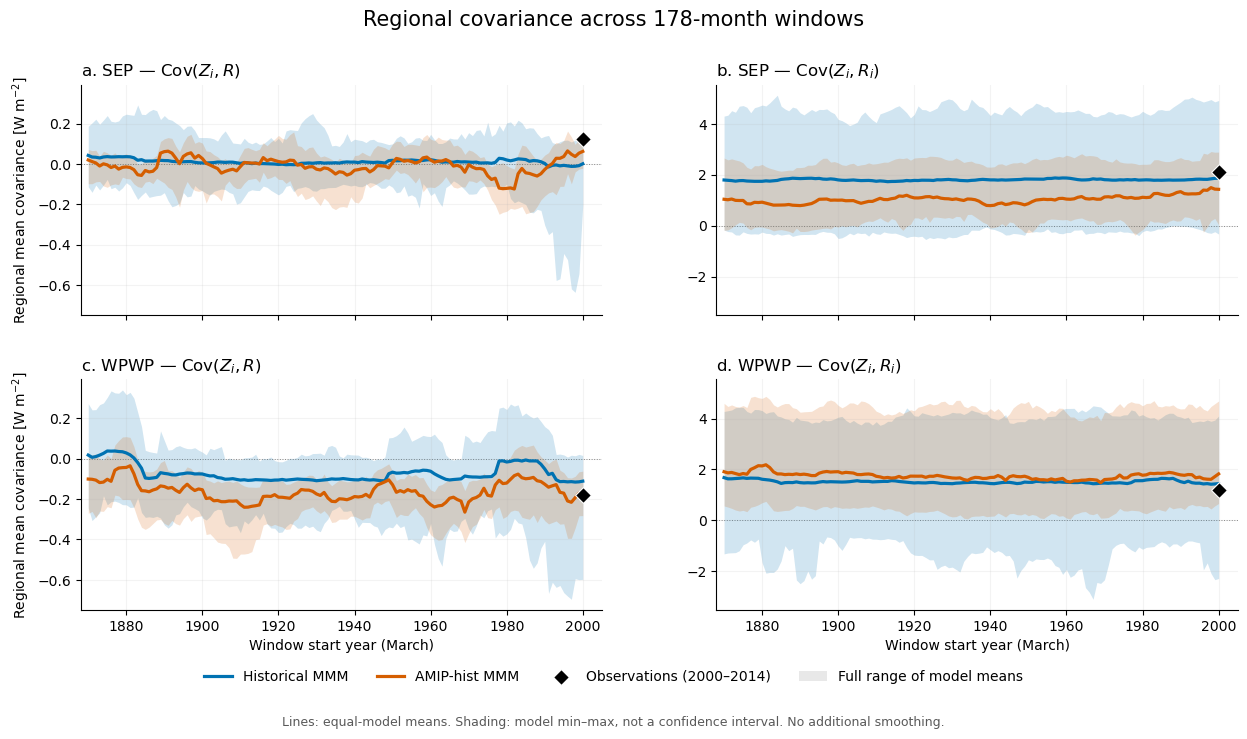

In [11]:
# %% Four panels: SEP/WPWP regional means, equal-model MMMs, and full model ranges
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# Read only the small REGIONAL result bundle, not the original map files.
# Alternatively, replace this load with regional_plot_archive = loaded_regional
# or regional_plot_archive = stationarity_regional_archive for unsaved results.
regional_plot_path = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/regional/march_n178_regional.npy")
regional_plot_archive = np.load(regional_plot_path, allow_pickle=True).item()

# Full historical is the default; choose historical_matched for the AMIP-matched
# model population. No members are pooled across models or plotted individually.
historical_group = "historical"           # Or "historical_matched".
regional_plot_experiments = [historical_group, "amip_hist"]
regional_plot_regions = ["SEP", "WPWP"]
regional_plot_quantities = ["cov_Zi_R", "cov_Zi_Ri"]
regional_plot_colors = {historical_group: "#0072B2", "amip_hist": "#D55E00"}
regional_plot_labels = {historical_group: "Historical" if historical_group == "historical" else "Historical (matched)",
                        "amip_hist": "AMIP-hist"}
regional_plot_titles = {"cov_Zi_R": r"$\mathrm{Cov}(Z_i,R)$", "cov_Zi_Ri": r"$\mathrm{Cov}(Z_i,R_i)$"}
regional_plot_alpha, regional_plot_lw = 0.18, 2.3
regional_plot_savepath = None             # Optional output filename, e.g. "./regional_stationarity.png".

# The x coordinate is WINDOW START YEAR, not the window midpoint/end year.
# The observation represents March 2000–December 2014 and therefore sits at 2000,
# exactly aligned with the final model window, not displaced to 2001 for display.
regional_plot_years = np.asarray(regional_plot_archive["metadata"]["start_years"])
regional_plot_obs_year = int(regional_plot_archive["metadata"]["observation_period"][:4])
if (regional_plot_years.ndim != 1 or not len(regional_plot_years)
        or not np.isfinite(regional_plot_years).all() or np.any(np.diff(regional_plot_years) <= 0)):
    raise ValueError("Expected finite, increasing window-start years.")


def regional_plot_mean(values):
    """Finite arithmetic mean over axis 0, with counts; empty years remain NaN."""
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan, dtype=float), where=count > 0), count


# Summarize each member series INTO ITS MODEL first, then give each model one
# vote in the MMM. Min/max are taken across those model means at EACH start year.
# The shaded boundary can change which model supplies the extreme through time.
regional_plot_summary = {e: {} for e in regional_plot_experiments}
for experiment in regional_plot_experiments:
    names = list(regional_plot_archive["metadata"]["model_names"][experiment])
    if not names or len(names) != len(set(names)):
        raise ValueError(f"{experiment}: expected a nonempty list of unique model names.")
    for quantity in regional_plot_quantities:
        regional_plot_summary[experiment][quantity] = {}
        for region in regional_plot_regions:
            model_means, member_counts = [], []
            for model in names:
                members = np.ma.asarray(regional_plot_archive["member_values"][experiment][quantity][region][model],
                                        dtype=float).filled(np.nan)
                if members.ndim != 2 or members.shape[0] == 0 or members.shape[1] != len(regional_plot_years):
                    raise ValueError(f"{experiment}/{quantity}/{region}/{model}: expected (member, start_year).")
                mean, count = regional_plot_mean(members)
                model_means.append(mean)
                member_counts.append(count)
            model_means = np.stack(model_means)
            MMM, n_models = regional_plot_mean(model_means)
            finite = np.isfinite(model_means)
            lower = np.where(n_models > 0, np.min(np.where(finite, model_means, np.inf), axis=0), np.nan)
            upper = np.where(n_models > 0, np.max(np.where(finite, model_means, -np.inf), axis=0), np.nan)
            regional_plot_summary[experiment][quantity][region] = {
                "model_names": names.copy(), "model_means": model_means, "MMM": MMM,
                "minimum": lower, "maximum": upper, "n_models": n_models,
                "model_n_members": np.stack(member_counts),
            }

# Share y limits within each COLUMN so SEP and WPWP can be compared for a given
# diagnostic. The two columns retain independent scales because amplitudes differ.
fig_regional_stationarity, axes_regional_stationarity = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True, sharey="col")
fig_regional_stationarity.subplots_adjust(left=.09, right=.98, bottom=.17, top=.87, wspace=.22, hspace=.28)
for row, region in enumerate(regional_plot_regions):
    for column, quantity in enumerate(regional_plot_quantities):
        ax = axes_regional_stationarity[row, column]
        for experiment in regional_plot_experiments:
            summary = regional_plot_summary[experiment][quantity][region]
            color = regional_plot_colors[experiment]
            ax.fill_between(regional_plot_years, summary["minimum"], summary["maximum"],
                            where=summary["n_models"] >= 2, color=color, alpha=regional_plot_alpha, linewidth=0, zorder=1)
            ax.plot(regional_plot_years, summary["MMM"], color=color, lw=regional_plot_lw,
                    label=f"{regional_plot_labels[experiment]} MMM", zorder=3)

        # One fixed observational regional value, not a moving observation series.
        observation = float(regional_plot_archive["observations"][quantity][region])
        ax.scatter([regional_plot_obs_year], [observation], marker="D", s=65, color="black",
                   edgecolors="white", linewidths=.8, label="Observations (2000–2014)", zorder=6)
        ax.axhline(0, color="0.5", lw=.7, ls=":", zorder=0)
        ax.set_title(f"{'abcd'[2*row+column]}. {region} — {regional_plot_titles[quantity]}", fontsize=12, loc="left")
        ax.set_xlim(min(regional_plot_years[0], regional_plot_obs_year) - 2,
                    max(regional_plot_years[-1], regional_plot_obs_year) + 5)
        ax.grid(alpha=.15)
        ax.spines[["top", "right"]].set_visible(False)
        if row == 1:
            ax.set_xlabel("Window start year (March)")
        if column == 0:
            ax.set_ylabel(r"Regional mean covariance [W m$^{-2}$]")

handles, labels = axes_regional_stationarity[0, 0].get_legend_handles_labels()
handles.append(Patch(facecolor="0.5", alpha=regional_plot_alpha, edgecolor="none"))
labels.append("Full range of model means")
fig_regional_stationarity.legend(handles, labels, loc="lower center", bbox_to_anchor=(.5, .055), ncol=4, frameon=False)
fig_regional_stationarity.suptitle("Regional covariance across 178-month windows", fontsize=15, y=.97)
fig_regional_stationarity.text(.5, .015, "Lines: equal-model means. Shading: model min–max, not a confidence interval. No additional smoothing.",
                               ha="center", fontsize=9, color="0.35")
if regional_plot_savepath is not None:
    regional_plot_savepath = Path(regional_plot_savepath)
    regional_plot_savepath.parent.mkdir(parents=True, exist_ok=True)
    fig_regional_stationarity.savefig(regional_plot_savepath, dpi=200, bbox_inches="tight")
plt.show()


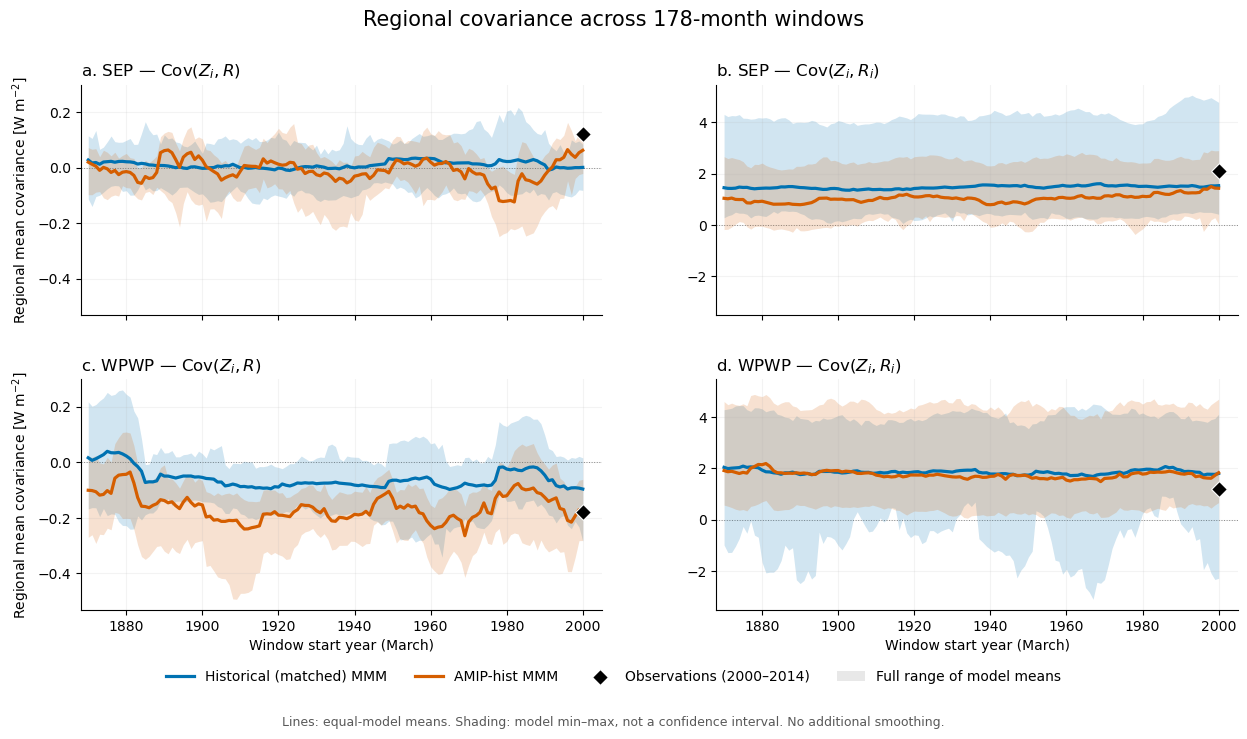

In [12]:
# %% Four panels: SEP/WPWP regional means, equal-model MMMs, and full model ranges
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# Read only the small REGIONAL result bundle, not the original map files.
# Alternatively, replace this load with regional_plot_archive = loaded_regional
# or regional_plot_archive = stationarity_regional_archive for unsaved results.
regional_plot_path = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/regional/march_n178_regional.npy")
regional_plot_archive = np.load(regional_plot_path, allow_pickle=True).item()

# Full historical is the default; choose historical_matched for the AMIP-matched
# model population. No members are pooled across models or plotted individually.
historical_group = "historical_matched"           # Or "historical_matched".
regional_plot_experiments = [historical_group, "amip_hist"]
regional_plot_regions = ["SEP", "WPWP"]
regional_plot_quantities = ["cov_Zi_R", "cov_Zi_Ri"]
regional_plot_colors = {historical_group: "#0072B2", "amip_hist": "#D55E00"}
regional_plot_labels = {historical_group: "Historical" if historical_group == "historical" else "Historical (matched)",
                        "amip_hist": "AMIP-hist"}
regional_plot_titles = {"cov_Zi_R": r"$\mathrm{Cov}(Z_i,R)$", "cov_Zi_Ri": r"$\mathrm{Cov}(Z_i,R_i)$"}
regional_plot_alpha, regional_plot_lw = 0.18, 2.3
regional_plot_savepath = None             # Optional output filename, e.g. "./regional_stationarity.png".

# The x coordinate is WINDOW START YEAR, not the window midpoint/end year.
# The observation represents March 2000–December 2014 and therefore sits at 2000,
# exactly aligned with the final model window, not displaced to 2001 for display.
regional_plot_years = np.asarray(regional_plot_archive["metadata"]["start_years"])
regional_plot_obs_year = int(regional_plot_archive["metadata"]["observation_period"][:4])
if (regional_plot_years.ndim != 1 or not len(regional_plot_years)
        or not np.isfinite(regional_plot_years).all() or np.any(np.diff(regional_plot_years) <= 0)):
    raise ValueError("Expected finite, increasing window-start years.")


def regional_plot_mean(values):
    """Finite arithmetic mean over axis 0, with counts; empty years remain NaN."""
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan, dtype=float), where=count > 0), count


# Summarize each member series INTO ITS MODEL first, then give each model one
# vote in the MMM. Min/max are taken across those model means at EACH start year.
# The shaded boundary can change which model supplies the extreme through time.
regional_plot_summary = {e: {} for e in regional_plot_experiments}
for experiment in regional_plot_experiments:
    names = list(regional_plot_archive["metadata"]["model_names"][experiment])
    if not names or len(names) != len(set(names)):
        raise ValueError(f"{experiment}: expected a nonempty list of unique model names.")
    for quantity in regional_plot_quantities:
        regional_plot_summary[experiment][quantity] = {}
        for region in regional_plot_regions:
            model_means, member_counts = [], []
            for model in names:
                members = np.ma.asarray(regional_plot_archive["member_values"][experiment][quantity][region][model],
                                        dtype=float).filled(np.nan)
                if members.ndim != 2 or members.shape[0] == 0 or members.shape[1] != len(regional_plot_years):
                    raise ValueError(f"{experiment}/{quantity}/{region}/{model}: expected (member, start_year).")
                mean, count = regional_plot_mean(members)
                model_means.append(mean)
                member_counts.append(count)
            model_means = np.stack(model_means)
            MMM, n_models = regional_plot_mean(model_means)
            finite = np.isfinite(model_means)
            lower = np.where(n_models > 0, np.min(np.where(finite, model_means, np.inf), axis=0), np.nan)
            upper = np.where(n_models > 0, np.max(np.where(finite, model_means, -np.inf), axis=0), np.nan)
            regional_plot_summary[experiment][quantity][region] = {
                "model_names": names.copy(), "model_means": model_means, "MMM": MMM,
                "minimum": lower, "maximum": upper, "n_models": n_models,
                "model_n_members": np.stack(member_counts),
            }

# Share y limits within each COLUMN so SEP and WPWP can be compared for a given
# diagnostic. The two columns retain independent scales because amplitudes differ.
fig_regional_stationarity, axes_regional_stationarity = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True, sharey="col")
fig_regional_stationarity.subplots_adjust(left=.09, right=.98, bottom=.17, top=.87, wspace=.22, hspace=.28)
for row, region in enumerate(regional_plot_regions):
    for column, quantity in enumerate(regional_plot_quantities):
        ax = axes_regional_stationarity[row, column]
        for experiment in regional_plot_experiments:
            summary = regional_plot_summary[experiment][quantity][region]
            color = regional_plot_colors[experiment]
            ax.fill_between(regional_plot_years, summary["minimum"], summary["maximum"],
                            where=summary["n_models"] >= 2, color=color, alpha=regional_plot_alpha, linewidth=0, zorder=1)
            ax.plot(regional_plot_years, summary["MMM"], color=color, lw=regional_plot_lw,
                    label=f"{regional_plot_labels[experiment]} MMM", zorder=3)

        # One fixed observational regional value, not a moving observation series.
        observation = float(regional_plot_archive["observations"][quantity][region])
        ax.scatter([regional_plot_obs_year], [observation], marker="D", s=65, color="black",
                   edgecolors="white", linewidths=.8, label="Observations (2000–2014)", zorder=6)
        ax.axhline(0, color="0.5", lw=.7, ls=":", zorder=0)
        ax.set_title(f"{'abcd'[2*row+column]}. {region} — {regional_plot_titles[quantity]}", fontsize=12, loc="left")
        ax.set_xlim(min(regional_plot_years[0], regional_plot_obs_year) - 2,
                    max(regional_plot_years[-1], regional_plot_obs_year) + 5)
        ax.grid(alpha=.15)
        ax.spines[["top", "right"]].set_visible(False)
        if row == 1:
            ax.set_xlabel("Window start year (March)")
        if column == 0:
            ax.set_ylabel(r"Regional mean covariance [W m$^{-2}$]")

handles, labels = axes_regional_stationarity[0, 0].get_legend_handles_labels()
handles.append(Patch(facecolor="0.5", alpha=regional_plot_alpha, edgecolor="none"))
labels.append("Full range of model means")
fig_regional_stationarity.legend(handles, labels, loc="lower center", bbox_to_anchor=(.5, .055), ncol=4, frameon=False)
fig_regional_stationarity.suptitle("Regional covariance across 178-month windows", fontsize=15, y=.97)
fig_regional_stationarity.text(.5, .015, "Lines: equal-model means. Shading: model min–max, not a confidence interval. No additional smoothing.",
                               ha="center", fontsize=9, color="0.35")
if regional_plot_savepath is not None:
    regional_plot_savepath = Path(regional_plot_savepath)
    regional_plot_savepath.parent.mkdir(parents=True, exist_ok=True)
    fig_regional_stationarity.savefig(regional_plot_savepath, dpi=200, bbox_inches="tight")
plt.show()


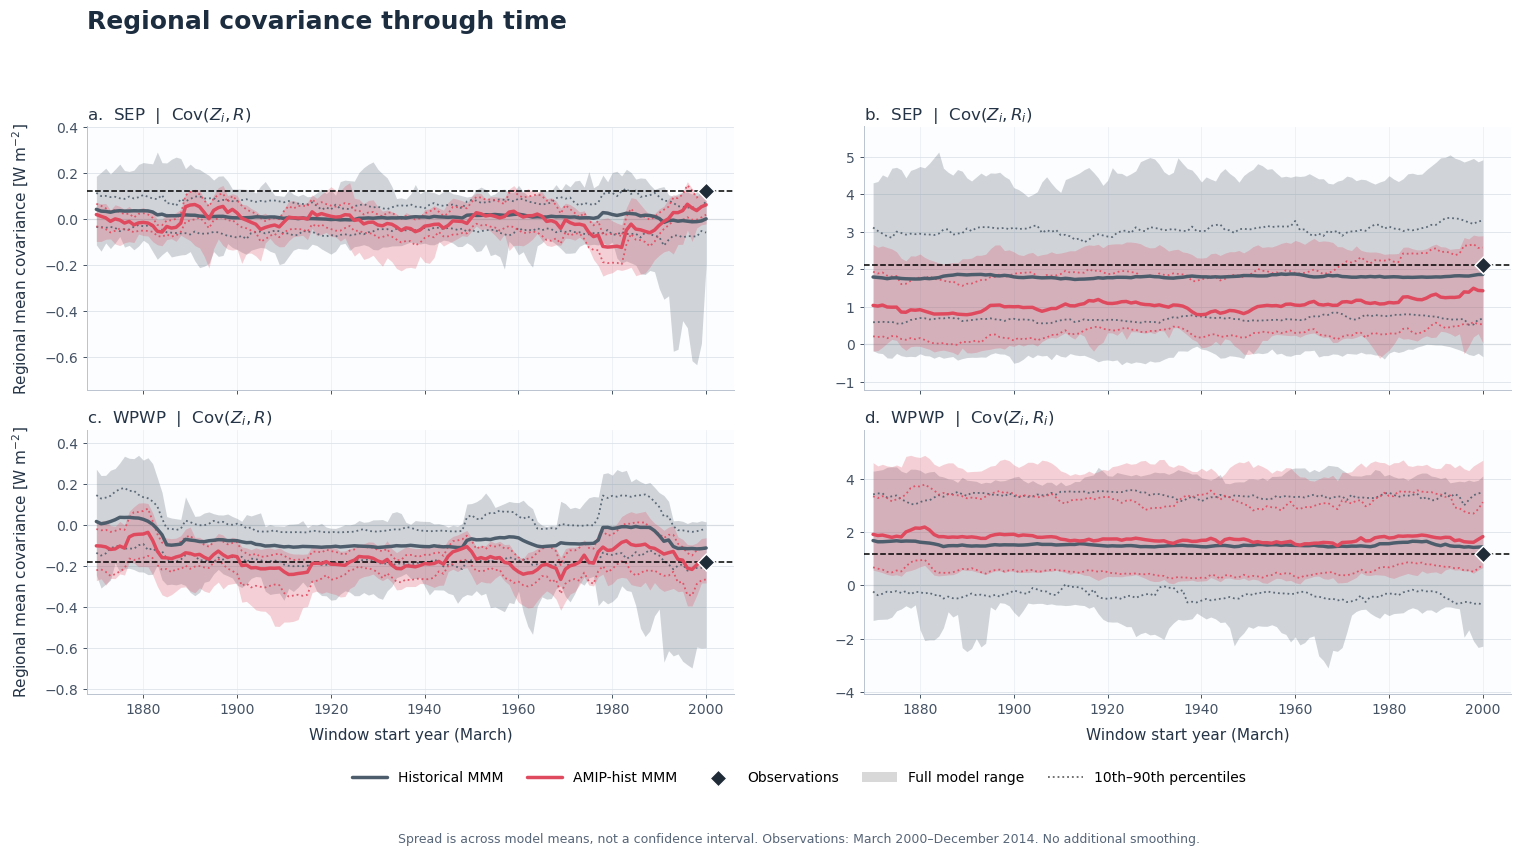

In [15]:
# %% Four panels: SEP/WPWP MMMs, full model ranges, and central-80% boundaries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path

# Read only the small REGIONAL result bundle, not the original map files.
# Alternatively, replace this load with regional_plot_archive = loaded_regional
# or regional_plot_archive = stationarity_regional_archive for unsaved results.
regional_plot_path = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/regional/march_n178_regional.npy")
regional_plot_archive = np.load(regional_plot_path, allow_pickle=True).item()

# Full historical is the default; choose historical_matched for the AMIP-matched
# model population. No members are pooled across models or plotted individually.
historical_group = "historical"           # Or "historical_matched".
regional_plot_experiments = [historical_group, "amip_hist"]
regional_plot_regions = ["SEP", "WPWP"]
regional_plot_quantities = ["cov_Zi_R", "cov_Zi_Ri"]

regional_plot_colors = {historical_group: "#2166AC", "amip_hist": "#D66B27"}
regional_plot_colors = {historical_group: "#4E5D6C", "amip_hist": "#E04A5F"}

regional_plot_labels = {historical_group: "Historical" if historical_group == "historical" else "Historical (matched)",
                        "amip_hist": "AMIP-hist"}
regional_plot_titles = {"cov_Zi_R": r"$\mathrm{Cov}(Z_i,R)$", "cov_Zi_Ri": r"$\mathrm{Cov}(Z_i,R_i)$"}
regional_plot_alpha, regional_plot_lw = 0.25, 2.5
regional_plot_percentile_lw = 1.3
regional_plot_savepath = "/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/maps/MMM_historical.png"           
# Optional output filename, e.g. "./regional_stationarity.png".

# The x coordinate is WINDOW START YEAR, not the window midpoint/end year.
# The observation represents March 2000–December 2014 and therefore sits at 2000,
# exactly aligned with the final model window, not displaced to 2001 for display.
regional_plot_years = np.asarray(regional_plot_archive["metadata"]["start_years"])
regional_plot_obs_year = int(regional_plot_archive["metadata"]["observation_period"][:4])
if (regional_plot_years.ndim != 1 or not len(regional_plot_years)
        or not np.isfinite(regional_plot_years).all() or np.any(np.diff(regional_plot_years) <= 0)):
    raise ValueError("Expected finite, increasing window-start years.")


def regional_plot_mean(values):
    """Finite arithmetic mean over axis 0, with counts; empty years remain NaN."""
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan, dtype=float), where=count > 0), count


# Summarize each member series INTO ITS MODEL first, then give each model one
# vote in the MMM. Min/max are taken across those model means at EACH start year.
# The shaded boundary can change which model supplies the extreme through time.
# Central 80% means the 10th/90th percentiles of MODEL MEANS, not member values,
# not 80% of the min–max width, and not a confidence interval around the MMM.
regional_plot_summary = {e: {} for e in regional_plot_experiments}
for experiment in regional_plot_experiments:
    names = list(regional_plot_archive["metadata"]["model_names"][experiment])
    if not names or len(names) != len(set(names)):
        raise ValueError(f"{experiment}: expected a nonempty list of unique model names.")
    for quantity in regional_plot_quantities:
        regional_plot_summary[experiment][quantity] = {}
        for region in regional_plot_regions:
            model_means, member_counts = [], []
            for model in names:
                members = np.ma.asarray(regional_plot_archive["member_values"][experiment][quantity][region][model],
                                        dtype=float).filled(np.nan)
                if members.ndim != 2 or members.shape[0] == 0 or members.shape[1] != len(regional_plot_years):
                    raise ValueError(f"{experiment}/{quantity}/{region}/{model}: expected (member, start_year).")
                mean, count = regional_plot_mean(members)
                model_means.append(mean)
                member_counts.append(count)
            model_means = np.stack(model_means)
            MMM, n_models = regional_plot_mean(model_means)
            finite = np.isfinite(model_means)
            lower = np.where(n_models > 0, np.min(np.where(finite, model_means, np.inf), axis=0), np.nan)
            upper = np.where(n_models > 0, np.max(np.where(finite, model_means, -np.inf), axis=0), np.nan)
            p10, p90 = np.full(len(regional_plot_years), np.nan), np.full(len(regional_plot_years), np.nan)
            has_models = n_models > 0
            if has_models.any():
                # Default linear percentile interpolation; all-missing years are
                # excluded first, so they stay NaN without producing warnings.
                p10[has_models], p90[has_models] = np.nanpercentile(model_means[:, has_models], [10, 90], axis=0)
            regional_plot_summary[experiment][quantity][region] = {
                "model_names": names.copy(), "model_means": model_means, "MMM": MMM,
                "minimum": lower, "maximum": upper, "n_models": n_models,
                "p10": p10, "p90": p90,
                "model_n_members": np.stack(member_counts),
            }

# Share y limits within each COLUMN so SEP and WPWP can be compared for a given
# diagnostic. The two columns retain independent scales because amplitudes differ.
fig_regional_stationarity, axes_regional_stationarity = plt.subplots(2, 2, figsize=(16, 9), sharex=True, #sharey="col",
                                                                  facecolor="white")
fig_regional_stationarity.subplots_adjust(left=.085, right=.975, bottom=.19, top=.82, wspace=.20, hspace=.150)
for row, region in enumerate(regional_plot_regions):
    for column, quantity in enumerate(regional_plot_quantities):
        ax = axes_regional_stationarity[row, column]
        for experiment in regional_plot_experiments:
            summary = regional_plot_summary[experiment][quantity][region]
            color = regional_plot_colors[experiment]
            ax.fill_between(regional_plot_years, summary["minimum"], summary["maximum"],
                            where=summary["n_models"] >= 2, color=color, alpha=regional_plot_alpha, linewidth=0, zorder=1)

            # Keep the full spread in the background; dotted bounds reveal the
            # central 80% without letting an extreme model define this envelope.
            # With only one valid model, show its MMM but no spread boundaries.
            for percentile in ["p10", "p90"]:
                boundary = np.where(summary["n_models"] >= 2, summary[percentile], np.nan)
                ax.plot(regional_plot_years, boundary, color=color, lw=regional_plot_percentile_lw,
                        linestyle=":", alpha=.9, zorder=2)
            ax.plot(regional_plot_years, summary["MMM"], color=color, lw=regional_plot_lw,
                    label=f"{regional_plot_labels[experiment]} MMM", solid_capstyle="round", zorder=4)

        # The horizontal dashed line shows this panel's observed covariance VALUE.
        # It is a fixed reference, not observations measured in every model window.
        observation = float(regional_plot_archive["observations"][quantity][region])
        if np.isfinite(observation):
            ax.axhline(observation, color="black", lw=1.1, linestyle="--", zorder=3)
        ax.scatter([regional_plot_obs_year], [observation], marker="D", s=75, color="#202B38",
                   edgecolors="white", linewidths=1.1, label="Observations", zorder=6)
        ax.axhline(0, color="0.55", lw=.8, linestyle="-", alpha=.6, zorder=0)
        ax.set_title(f"{'abcd'[2*row+column]}.  {region}  |  {regional_plot_titles[quantity]}",
                     fontsize=12, fontweight="medium", color="#253446", loc="left", pad=5)
        ax.set_xlim(min(regional_plot_years[0], regional_plot_obs_year) - 2,
                    max(regional_plot_years[-1], regional_plot_obs_year) + 6)
        ax.set_facecolor("#FCFDFE")
        ax.set_axisbelow(True)
        ax.grid(axis="y", color="#DDE3EA", linewidth=.6)
        ax.grid(axis="x", color="#E9EDF2", linewidth=.5)
        ax.spines[["top", "right"]].set_visible(False)
        for side in ["bottom", "left"]:
            ax.spines[side].set_color("#B9C3CF")
            ax.spines[side].set_linewidth(.7)
        ax.tick_params(axis="both", labelsize=10, colors="#445264", length=3, width=.7)
        ax.margins(y=.12)
        if row == 1:
            ax.set_xlabel("Window start year (March)", fontsize=11, labelpad=8, color="#253446")
        if column == 0:
            ax.set_ylabel(r"Regional mean covariance [W m$^{-2}$]", fontsize=11, labelpad=9, color="#253446")

handles, labels = axes_regional_stationarity[0, 0].get_legend_handles_labels()
handles += [Patch(facecolor="0.4", alpha=regional_plot_alpha, edgecolor="none"),
            Line2D([], [], color="0.4", lw=regional_plot_percentile_lw, linestyle=":")]
labels += ["Full model range", "10th–90th percentiles"]
fig_regional_stationarity.legend(handles, labels, loc="lower center", bbox_to_anchor=(.53, .075),
                                 ncol=5, frameon=False, fontsize=10, handlelength=2.5, columnspacing=1.7)
fig_regional_stationarity.suptitle("Regional covariance through time", fontsize=18, fontweight="bold",
                                   x=.085, y=.95, ha="left", color="#1D2D40")
window_months = regional_plot_archive["metadata"].get("window_months", 178)
# fig_regional_stationarity.text(.085, .91, f"{window_months}-month windows  ·  Equal model weighting  ·  Black dashed reference: observed covariance",
#                                fontsize=10.5, color="#566578", ha="left")
fig_regional_stationarity.text(.53, .025, 
        "Spread is across model means, not a confidence interval. Observations: March 2000–December 2014. No additional smoothing.",
                               ha="center", fontsize=9, color="#566578")
if regional_plot_savepath is not None:
    regional_plot_savepath = Path(regional_plot_savepath)
    regional_plot_savepath.parent.mkdir(parents=True, exist_ok=True)
    fig_regional_stationarity.savefig(regional_plot_savepath, dpi=200, bbox_inches="tight")
plt.show()


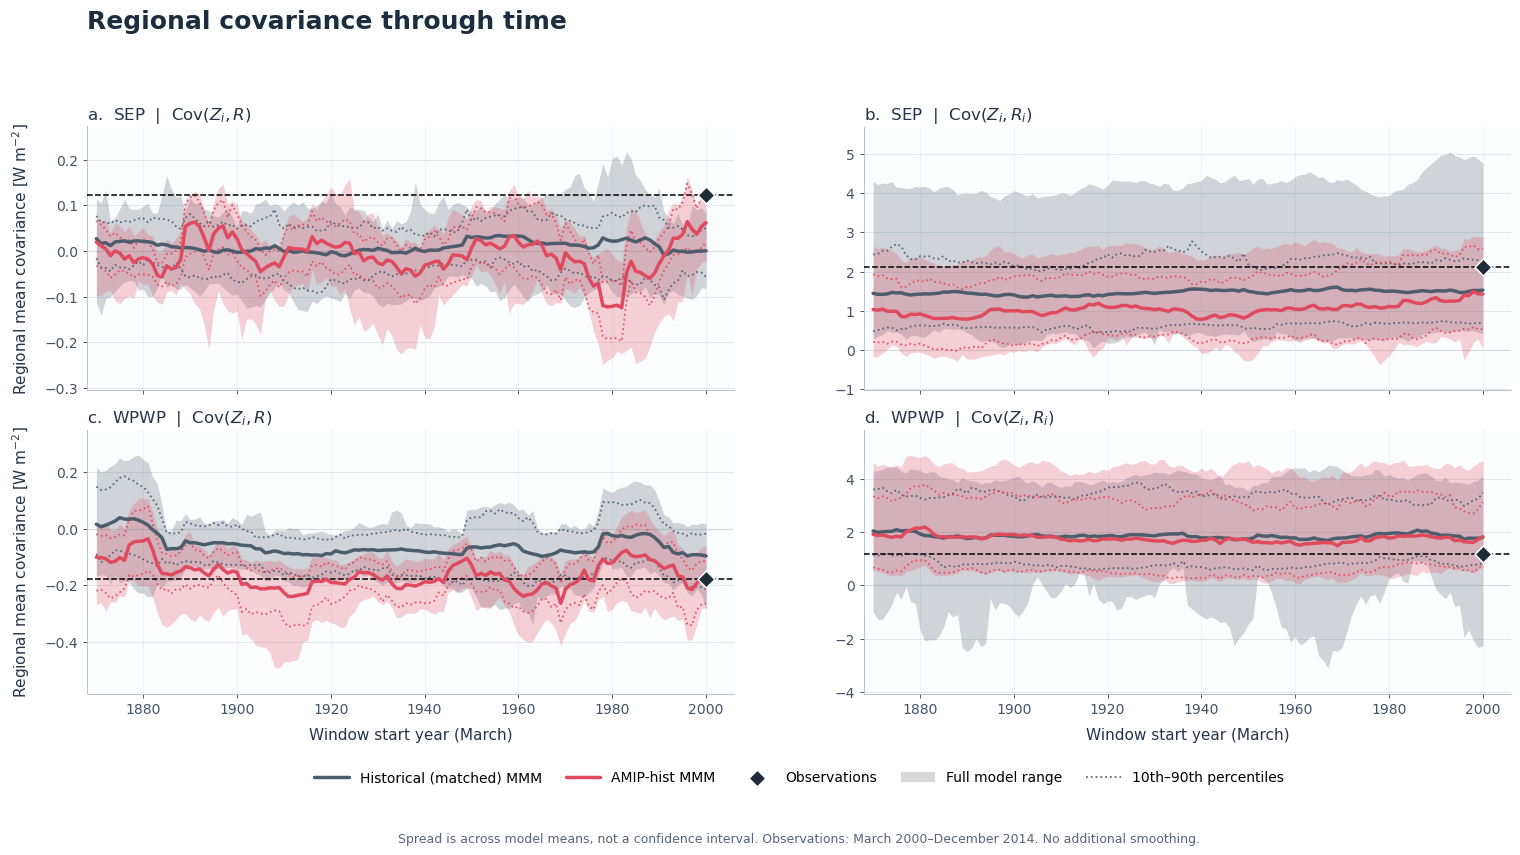

In [16]:
# %% Four panels: SEP/WPWP MMMs, full model ranges, and central-80% boundaries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path

# Read only the small REGIONAL result bundle, not the original map files.
# Alternatively, replace this load with regional_plot_archive = loaded_regional
# or regional_plot_archive = stationarity_regional_archive for unsaved results.
regional_plot_path = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/regional/march_n178_regional.npy")
regional_plot_archive = np.load(regional_plot_path, allow_pickle=True).item()

# Full historical is the default; choose historical_matched for the AMIP-matched
# model population. No members are pooled across models or plotted individually.
historical_group = "historical_matched"           # Or "historical_matched".
regional_plot_experiments = [historical_group, "amip_hist"]
regional_plot_regions = ["SEP", "WPWP"]
regional_plot_quantities = ["cov_Zi_R", "cov_Zi_Ri"]

regional_plot_colors = {historical_group: "#2166AC", "amip_hist": "#D66B27"}
regional_plot_colors = {historical_group: "#4E5D6C", "amip_hist": "#E04A5F"}

regional_plot_labels = {historical_group: "Historical" if historical_group == "historical" else "Historical (matched)",
                        "amip_hist": "AMIP-hist"}
regional_plot_titles = {"cov_Zi_R": r"$\mathrm{Cov}(Z_i,R)$", "cov_Zi_Ri": r"$\mathrm{Cov}(Z_i,R_i)$"}
regional_plot_alpha, regional_plot_lw = 0.25, 2.5
regional_plot_percentile_lw = 1.3
regional_plot_savepath = "/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/maps/MMM_historical.png"           
# Optional output filename, e.g. "./regional_stationarity.png".

# The x coordinate is WINDOW START YEAR, not the window midpoint/end year.
# The observation represents March 2000–December 2014 and therefore sits at 2000,
# exactly aligned with the final model window, not displaced to 2001 for display.
regional_plot_years = np.asarray(regional_plot_archive["metadata"]["start_years"])
regional_plot_obs_year = int(regional_plot_archive["metadata"]["observation_period"][:4])
if (regional_plot_years.ndim != 1 or not len(regional_plot_years)
        or not np.isfinite(regional_plot_years).all() or np.any(np.diff(regional_plot_years) <= 0)):
    raise ValueError("Expected finite, increasing window-start years.")


def regional_plot_mean(values):
    """Finite arithmetic mean over axis 0, with counts; empty years remain NaN."""
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan, dtype=float), where=count > 0), count


# Summarize each member series INTO ITS MODEL first, then give each model one
# vote in the MMM. Min/max are taken across those model means at EACH start year.
# The shaded boundary can change which model supplies the extreme through time.
# Central 80% means the 10th/90th percentiles of MODEL MEANS, not member values,
# not 80% of the min–max width, and not a confidence interval around the MMM.
regional_plot_summary = {e: {} for e in regional_plot_experiments}
for experiment in regional_plot_experiments:
    names = list(regional_plot_archive["metadata"]["model_names"][experiment])
    if not names or len(names) != len(set(names)):
        raise ValueError(f"{experiment}: expected a nonempty list of unique model names.")
    for quantity in regional_plot_quantities:
        regional_plot_summary[experiment][quantity] = {}
        for region in regional_plot_regions:
            model_means, member_counts = [], []
            for model in names:
                members = np.ma.asarray(regional_plot_archive["member_values"][experiment][quantity][region][model],
                                        dtype=float).filled(np.nan)
                if members.ndim != 2 or members.shape[0] == 0 or members.shape[1] != len(regional_plot_years):
                    raise ValueError(f"{experiment}/{quantity}/{region}/{model}: expected (member, start_year).")
                mean, count = regional_plot_mean(members)
                model_means.append(mean)
                member_counts.append(count)
            model_means = np.stack(model_means)
            MMM, n_models = regional_plot_mean(model_means)
            finite = np.isfinite(model_means)
            lower = np.where(n_models > 0, np.min(np.where(finite, model_means, np.inf), axis=0), np.nan)
            upper = np.where(n_models > 0, np.max(np.where(finite, model_means, -np.inf), axis=0), np.nan)
            p10, p90 = np.full(len(regional_plot_years), np.nan), np.full(len(regional_plot_years), np.nan)
            has_models = n_models > 0
            if has_models.any():
                # Default linear percentile interpolation; all-missing years are
                # excluded first, so they stay NaN without producing warnings.
                p10[has_models], p90[has_models] = np.nanpercentile(model_means[:, has_models], [10, 90], axis=0)
            regional_plot_summary[experiment][quantity][region] = {
                "model_names": names.copy(), "model_means": model_means, "MMM": MMM,
                "minimum": lower, "maximum": upper, "n_models": n_models,
                "p10": p10, "p90": p90,
                "model_n_members": np.stack(member_counts),
            }

# Share y limits within each COLUMN so SEP and WPWP can be compared for a given
# diagnostic. The two columns retain independent scales because amplitudes differ.
fig_regional_stationarity, axes_regional_stationarity = plt.subplots(2, 2, figsize=(16, 9), sharex=True, #sharey="col",
                                                                  facecolor="white")
fig_regional_stationarity.subplots_adjust(left=.085, right=.975, bottom=.19, top=.82, wspace=.20, hspace=.150)
for row, region in enumerate(regional_plot_regions):
    for column, quantity in enumerate(regional_plot_quantities):
        ax = axes_regional_stationarity[row, column]
        for experiment in regional_plot_experiments:
            summary = regional_plot_summary[experiment][quantity][region]
            color = regional_plot_colors[experiment]
            ax.fill_between(regional_plot_years, summary["minimum"], summary["maximum"],
                            where=summary["n_models"] >= 2, color=color, alpha=regional_plot_alpha, linewidth=0, zorder=1)

            # Keep the full spread in the background; dotted bounds reveal the
            # central 80% without letting an extreme model define this envelope.
            # With only one valid model, show its MMM but no spread boundaries.
            for percentile in ["p10", "p90"]:
                boundary = np.where(summary["n_models"] >= 2, summary[percentile], np.nan)
                ax.plot(regional_plot_years, boundary, color=color, lw=regional_plot_percentile_lw,
                        linestyle=":", alpha=.9, zorder=2)
            ax.plot(regional_plot_years, summary["MMM"], color=color, lw=regional_plot_lw,
                    label=f"{regional_plot_labels[experiment]} MMM", solid_capstyle="round", zorder=4)

        # The horizontal dashed line shows this panel's observed covariance VALUE.
        # It is a fixed reference, not observations measured in every model window.
        observation = float(regional_plot_archive["observations"][quantity][region])
        if np.isfinite(observation):
            ax.axhline(observation, color="black", lw=1.1, linestyle="--", zorder=3)
        ax.scatter([regional_plot_obs_year], [observation], marker="D", s=75, color="#202B38",
                   edgecolors="white", linewidths=1.1, label="Observations", zorder=6)
        ax.axhline(0, color="0.55", lw=.8, linestyle="-", alpha=.6, zorder=0)
        ax.set_title(f"{'abcd'[2*row+column]}.  {region}  |  {regional_plot_titles[quantity]}",
                     fontsize=12, fontweight="medium", color="#253446", loc="left", pad=5)
        ax.set_xlim(min(regional_plot_years[0], regional_plot_obs_year) - 2,
                    max(regional_plot_years[-1], regional_plot_obs_year) + 6)
        ax.set_facecolor("#FCFDFE")
        ax.set_axisbelow(True)
        ax.grid(axis="y", color="#DDE3EA", linewidth=.6)
        ax.grid(axis="x", color="#E9EDF2", linewidth=.5)
        ax.spines[["top", "right"]].set_visible(False)
        for side in ["bottom", "left"]:
            ax.spines[side].set_color("#B9C3CF")
            ax.spines[side].set_linewidth(.7)
        ax.tick_params(axis="both", labelsize=10, colors="#445264", length=3, width=.7)
        ax.margins(y=.12)
        if row == 1:
            ax.set_xlabel("Window start year (March)", fontsize=11, labelpad=8, color="#253446")
        if column == 0:
            ax.set_ylabel(r"Regional mean covariance [W m$^{-2}$]", fontsize=11, labelpad=9, color="#253446")

handles, labels = axes_regional_stationarity[0, 0].get_legend_handles_labels()
handles += [Patch(facecolor="0.4", alpha=regional_plot_alpha, edgecolor="none"),
            Line2D([], [], color="0.4", lw=regional_plot_percentile_lw, linestyle=":")]
labels += ["Full model range", "10th–90th percentiles"]
fig_regional_stationarity.legend(handles, labels, loc="lower center", bbox_to_anchor=(.53, .075),
                                 ncol=5, frameon=False, fontsize=10, handlelength=2.5, columnspacing=1.7)
fig_regional_stationarity.suptitle("Regional covariance through time", fontsize=18, fontweight="bold",
                                   x=.085, y=.95, ha="left", color="#1D2D40")
window_months = regional_plot_archive["metadata"].get("window_months", 178)
# fig_regional_stationarity.text(.085, .91, f"{window_months}-month windows  ·  Equal model weighting  ·  Black dashed reference: observed covariance",
#                                fontsize=10.5, color="#566578", ha="left")
fig_regional_stationarity.text(.53, .025, 
        "Spread is across model means, not a confidence interval. Observations: March 2000–December 2014. No additional smoothing.",
                               ha="center", fontsize=9, color="#566578")
if regional_plot_savepath is not None:
    regional_plot_savepath = Path(regional_plot_savepath)
    regional_plot_savepath.parent.mkdir(parents=True, exist_ok=True)
    fig_regional_stationarity.savefig(regional_plot_savepath, dpi=200, bbox_inches="tight")
plt.show()


historical_matched/cov_Zi_R/SEP: CI defined for 0/131 nonempty years. Singleton blockers: CNRM-CM6-1-HR, IITM-ESM, IPSL-CM6A-LR, MIROC6, MRI-ESM2-0, TaiESM1
historical_matched/cov_Zi_R/WPWP: CI defined for 0/131 nonempty years. Singleton blockers: CNRM-CM6-1-HR, IITM-ESM, IPSL-CM6A-LR, MIROC6, MRI-ESM2-0, TaiESM1
historical_matched/cov_Zi_Ri/SEP: CI defined for 0/131 nonempty years. Singleton blockers: CNRM-CM6-1-HR, IITM-ESM, IPSL-CM6A-LR, MIROC6, MRI-ESM2-0, TaiESM1
historical_matched/cov_Zi_Ri/WPWP: CI defined for 0/131 nonempty years. Singleton blockers: CNRM-CM6-1-HR, IITM-ESM, IPSL-CM6A-LR, MIROC6, MRI-ESM2-0, TaiESM1
amip_hist/cov_Zi_R/SEP: CI defined for 0/131 nonempty years. Singleton blockers: BCC-CSM2-MR, CNRM-CM6-1-HR, CNRM-ESM2-1, IITM-ESM
amip_hist/cov_Zi_R/WPWP: CI defined for 0/131 nonempty years. Singleton blockers: BCC-CSM2-MR, CNRM-CM6-1-HR, CNRM-ESM2-1, IITM-ESM
amip_hist/cov_Zi_Ri/SEP: CI defined for 0/131 nonempty years. Singleton blockers: BCC-CSM2-MR, CNRM-CM6-1

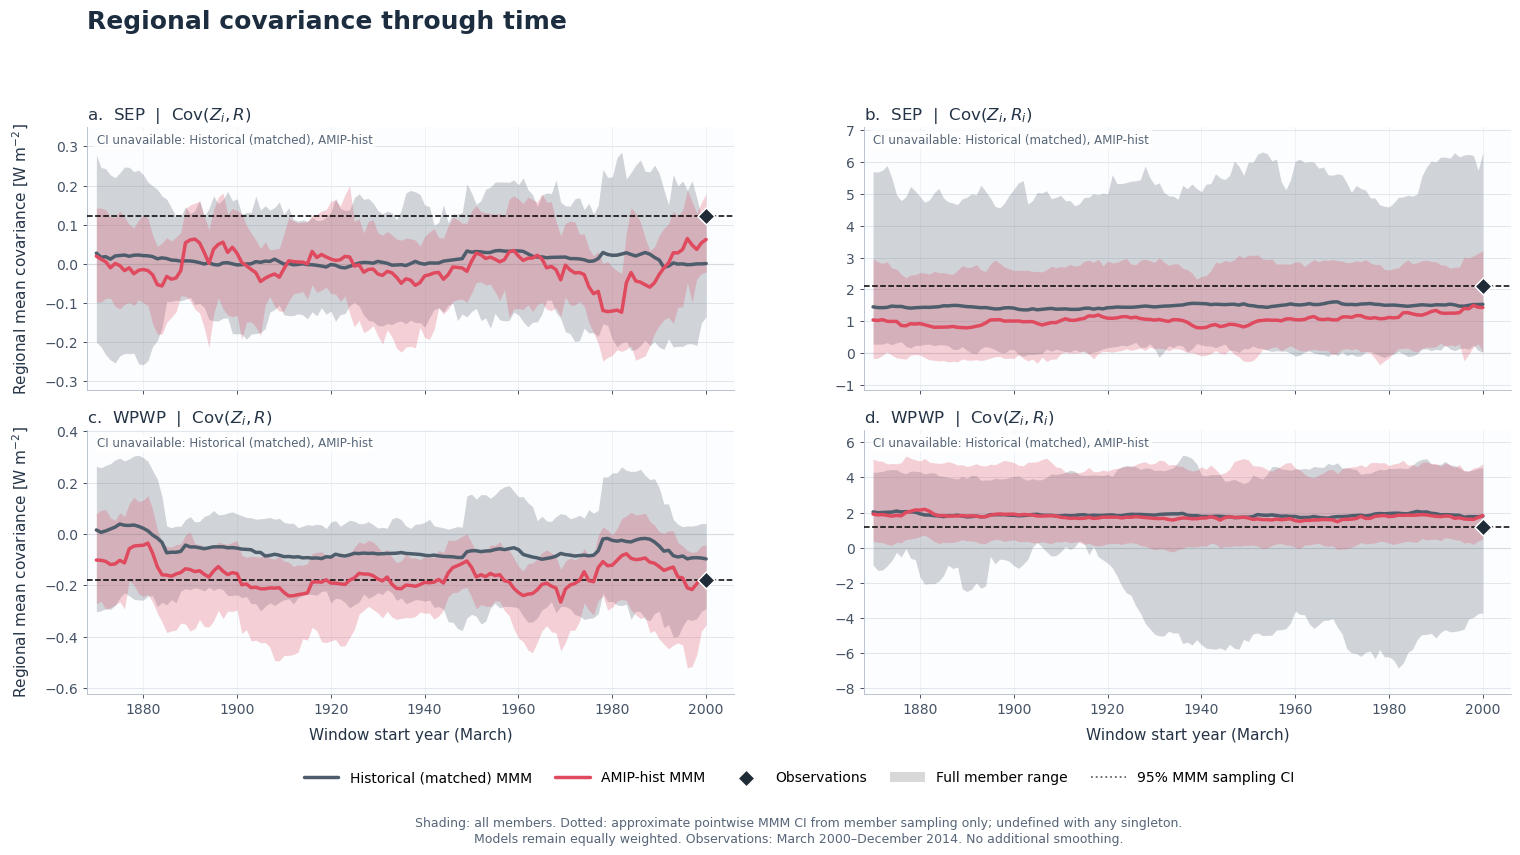

In [17]:
# %% Four panels: SEP/WPWP MMMs, all-member ranges, and finite-ensemble MMM CIs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats
from pathlib import Path

# Read only the small REGIONAL result bundle, not the original map files.
# Alternatively, replace this load with regional_plot_archive = loaded_regional
# or regional_plot_archive = stationarity_regional_archive for unsaved results.
regional_plot_path = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/regional/march_n178_regional.npy")
regional_plot_archive = np.load(regional_plot_path, allow_pickle=True).item()

# Matched historical is the default; choose historical for all coupled models.
# Members are pooled ONLY to find the descriptive min/max;
# the MMM and its confidence interval continue to give each model equal weight.
historical_group = "historical_matched"   # Or "historical" for all coupled models.
regional_plot_experiments = [historical_group, "amip_hist"]
regional_plot_regions = ["SEP", "WPWP"]
regional_plot_quantities = ["cov_Zi_R", "cov_Zi_Ri"]
regional_plot_colors = {historical_group: "#4E5D6C", "amip_hist": "#E04A5F"}
regional_plot_labels = {historical_group: "Historical" if historical_group == "historical" else "Historical (matched)",
                        "amip_hist": "AMIP-hist"}
regional_plot_titles = {"cov_Zi_R": r"$\mathrm{Cov}(Z_i,R)$", "cov_Zi_Ri": r"$\mathrm{Cov}(Z_i,R_i)$"}
regional_plot_alpha, regional_plot_lw = 0.25, 2.5
regional_plot_ci_lw, regional_plot_confidence = 1.3, 0.95  # Set confidence=0.80 for an 80% CI.
regional_plot_savepath = "/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/maps/MMM_historical.png"
# Set regional_plot_savepath = None to disable the figure save from your pasted cell.

# The x coordinate is WINDOW START YEAR, not the window midpoint/end year.
# The observation represents March 2000–December 2014 and therefore sits at 2000,
# exactly aligned with the final model window, not displaced to 2001 for display.
regional_plot_years = np.asarray(regional_plot_archive["metadata"]["start_years"])
regional_plot_obs_year = int(regional_plot_archive["metadata"]["observation_period"][:4])
if (regional_plot_years.ndim != 1 or not len(regional_plot_years)
        or not np.isfinite(regional_plot_years).all() or np.any(np.diff(regional_plot_years) <= 0)):
    raise ValueError("Expected finite, increasing window-start years.")


def regional_plot_mean(values):
    """Finite arithmetic mean over axis 0, with counts; empty years remain NaN."""
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan, dtype=float), where=count > 0), count


def regional_plot_mmm_ci(MMM, member_counts, member_variances, confidence=0.95):
    """Approximate pointwise CI for a fixed set of equally weighted model means.

    member_counts and member_variances have shape (model, start_year). Variances
    are WITHIN-model sample variances (ddof=1), not variance across model means.
    Assumes independent member sampling and independent sampling errors between
    models, with approximately normal mean errors. No model resampling or pooling
    of variances. Any contributing singleton makes that year's entire CI undefined.
    """
    if not 0 < confidence < 1:
        raise ValueError("Confidence must be between 0 and 1.")
    n_years = len(MMM)
    if member_counts.shape != member_variances.shape or member_counts.shape[1:] != (n_years,):
        raise ValueError("Expected matching (model, start_year) counts and variances.")
    se, df, lower, upper = [np.full(n_years, np.nan) for _ in range(4)]
    singleton_count = (member_counts == 1).sum(axis=0)

    # At each window, SE(MMM)^2 = sum(s_m^2/n_m)/M^2. Different ensemble sizes
    # change PRECISION, not the model weights in the MMM. No division by the
    # number of years: overlapping windows are not additional ensemble members.
    for year in range(n_years):
        contributes = member_counts[:, year] > 0
        n = member_counts[contributes, year]
        variances = member_variances[contributes, year]
        if (not len(n) or np.any(n < 2) or not np.isfinite(MMM[year])
                or not np.isfinite(variances).all() or np.any(variances < 0)):
            continue
        variance_terms = variances / n / len(n)**2
        variance_of_MMM = variance_terms.sum()
        se[year] = np.sqrt(variance_of_MMM)
        if variance_of_MMM == 0:
            # All estimated within-model variances are zero. This gives zero
            # estimated sampling error, not proof of zero population uncertainty.
            df[year], lower[year], upper[year] = np.inf, MMM[year], MMM[year]
            continue

        # Welch–Satterthwaite accounts approximately for uncertainty in each
        # estimated variance. Using variance shares avoids unnecessarily squaring
        # small physical-unit variances. Student-t is wider for low effective df.
        shares = variance_terms / variance_of_MMM
        df[year] = 1. / np.sum(shares**2 / (n - 1))
        halfwidth = stats.t.ppf((1 + confidence) / 2, df[year]) * se[year]
        lower[year], upper[year] = MMM[year] - halfwidth, MMM[year] + halfwidth
    return {"MMM_se": se, "ci_df": df, "ci_lower": lower, "ci_upper": upper,
            "ci_available": np.isfinite(lower) & np.isfinite(upper), "ci_singleton_models": singleton_count}


# Summarize each member series INTO ITS MODEL first, then give each model one
# vote in the MMM. Full-range shading now spans ALL individual member values.
# Models with more members have more opportunities to supply extreme values;
# that envelope is descriptive and is not an equal-model probability interval.
# Dotted lines now show an approximate CI for the fixed-model MMM, NOT the old
# 10th/90th model percentiles. Model choice, structural bias, observational error,
# and (for AMIP) uncertainty in the prescribed SST record are outside this CI.
regional_plot_summary = {e: {} for e in regional_plot_experiments}
for experiment in regional_plot_experiments:
    names = list(regional_plot_archive["metadata"]["model_names"][experiment])
    if not names or len(names) != len(set(names)):
        raise ValueError(f"{experiment}: expected a nonempty list of unique model names.")
    for quantity in regional_plot_quantities:
        regional_plot_summary[experiment][quantity] = {}
        for region in regional_plot_regions:
            model_means, member_counts, member_variances, all_members = [], [], [], []
            for model in names:
                members = np.ma.asarray(regional_plot_archive["member_values"][experiment][quantity][region][model],
                                        dtype=float).filled(np.nan)
                if members.ndim != 2 or members.shape[0] == 0 or members.shape[1] != len(regional_plot_years):
                    raise ValueError(f"{experiment}/{quantity}/{region}/{model}: expected (member, start_year).")
                mean, count = regional_plot_mean(members)
                # Estimate each model's member-to-member variance at this window.
                # Mask before subtraction so missing/inf inputs cannot contaminate
                # the sum. n=0 or 1 gives NaN variance, never a substituted zero.
                finite = np.isfinite(members)
                residual = np.where(finite, members, 0.) - np.where(np.isfinite(mean), mean, 0.)
                squared_deviations = np.sum(np.where(finite, residual, 0.)**2, axis=0)
                variance = np.divide(squared_deviations, count - 1, out=np.full_like(mean, np.nan), where=count >= 2)
                model_means.append(mean)
                member_counts.append(count)
                member_variances.append(variance)
                all_members.append(members)
            model_means = np.stack(model_means)
            member_counts, member_variances = np.stack(member_counts), np.stack(member_variances)
            MMM, n_models = regional_plot_mean(model_means)
            pooled_members = np.concatenate(all_members, axis=0)
            finite = np.isfinite(pooled_members)
            n_members = finite.sum(axis=0)
            lower = np.where(n_members > 0, np.min(np.where(finite, pooled_members, np.inf), axis=0), np.nan)
            upper = np.where(n_members > 0, np.max(np.where(finite, pooled_members, -np.inf), axis=0), np.nan)
            ci = regional_plot_mmm_ci(MMM, member_counts, member_variances, regional_plot_confidence)
            regional_plot_summary[experiment][quantity][region] = {
                "model_names": names.copy(), "model_means": model_means, "MMM": MMM,
                "member_minimum": lower, "member_maximum": upper, "n_models": n_models, "n_members": n_members,
                "model_n_members": member_counts, "model_member_variance": member_variances, **ci,
            }
            blockers = [name for i, name in enumerate(names) if np.any(member_counts[i] == 1)]
            print(f"{experiment}/{quantity}/{region}: CI defined for {ci['ci_available'].sum()}/{(n_models > 0).sum()} nonempty years."
                  + (f" Singleton blockers: {', '.join(blockers)}" if blockers else ""))

# Keep interpretation beside the plotting results; the saved input is untouched.
regional_plot_ci_metadata = {
    "confidence": regional_plot_confidence, "target": "Expected equal-model MMM for this fixed model set",
    "method": "Independent mean-error propagation; model-specific ddof=1 variances; Welch-Satterthwaite t interval",
    "singleton_policy": "Entire year CI undefined if any contributing model has one finite member; model remains in MMM/range",
    "coverage": "Approximate pointwise interval, not a simultaneous confidence band across overlapping years",
    "excluded": "Model selection, structural/shared bias, observation uncertainty, and prescribed-SST uncertainty",
    "sources": "Annotated bibliography entries 31–33; covariance/MMM implementation is a project adaptation",
}

# Preserve your revised presentation: independent y limits, matched historical,
# gray/red colors, 16x9 figure, tighter row spacing, and the original save location.
fig_regional_stationarity, axes_regional_stationarity = plt.subplots(2, 2, figsize=(16, 9), sharex=True,
                                                                  facecolor="white")
fig_regional_stationarity.subplots_adjust(left=.085, right=.975, bottom=.19, top=.82, wspace=.20, hspace=.150)
for row, region in enumerate(regional_plot_regions):
    for column, quantity in enumerate(regional_plot_quantities):
        ax = axes_regional_stationarity[row, column]
        for experiment in regional_plot_experiments:
            summary = regional_plot_summary[experiment][quantity][region]
            color = regional_plot_colors[experiment]
            ax.fill_between(regional_plot_years, summary["member_minimum"], summary["member_maximum"],
                            where=summary["n_members"] >= 2, color=color, alpha=regional_plot_alpha, linewidth=0, zorder=1)

            # Undefined intervals stay NaN, so lines have gaps (or are absent).
            # A singleton is NOT removed to manufacture an available interval.
            for key in ["ci_lower", "ci_upper"]:
                ax.plot(regional_plot_years, summary[key], color=color, lw=regional_plot_ci_lw,
                        linestyle=":", alpha=.9, zorder=2)
            ax.plot(regional_plot_years, summary["MMM"], color=color, lw=regional_plot_lw,
                    label=f"{regional_plot_labels[experiment]} MMM", solid_capstyle="round", zorder=4)

        # The horizontal dashed line shows this panel's observed covariance VALUE.
        # It is a fixed reference, not observations measured in every model window.
        observation = float(regional_plot_archive["observations"][quantity][region])
        if np.isfinite(observation):
            ax.axhline(observation, color="black", lw=1.1, linestyle="--", zorder=3)
        ax.scatter([regional_plot_obs_year], [observation], marker="D", s=75, color="#202B38",
                   edgecolors="white", linewidths=1.1, label="Observations", zorder=6)
        ax.axhline(0, color="0.55", lw=.8, linestyle="-", alpha=.6, zorder=0)
        ax.set_title(f"{'abcd'[2*row+column]}.  {region}  |  {regional_plot_titles[quantity]}",
                     fontsize=12, fontweight="medium", color="#253446", loc="left", pad=5)
        undefined_groups = [regional_plot_labels[e] for e in regional_plot_experiments
                            if not regional_plot_summary[e][quantity][region]["ci_available"].any()]
        if undefined_groups:
            ax.text(.015, .975, "CI unavailable: " + ", ".join(undefined_groups), transform=ax.transAxes,
                    ha="left", va="top", fontsize=8.5, color="#566578",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=.8, pad=2))
        ax.set_xlim(min(regional_plot_years[0], regional_plot_obs_year) - 2,
                    max(regional_plot_years[-1], regional_plot_obs_year) + 6)
        ax.set_facecolor("#FCFDFE")
        ax.set_axisbelow(True)
        ax.grid(axis="y", color="#DDE3EA", linewidth=.6)
        ax.grid(axis="x", color="#E9EDF2", linewidth=.5)
        ax.spines[["top", "right"]].set_visible(False)
        for side in ["bottom", "left"]:
            ax.spines[side].set_color("#B9C3CF")
            ax.spines[side].set_linewidth(.7)
        ax.tick_params(axis="both", labelsize=10, colors="#445264", length=3, width=.7)
        ax.margins(y=.12)
        if row == 1:
            ax.set_xlabel("Window start year (March)", fontsize=11, labelpad=8, color="#253446")
        if column == 0:
            ax.set_ylabel(r"Regional mean covariance [W m$^{-2}$]", fontsize=11, labelpad=9, color="#253446")

handles, labels = axes_regional_stationarity[0, 0].get_legend_handles_labels()
handles += [Patch(facecolor="0.4", alpha=regional_plot_alpha, edgecolor="none"),
            Line2D([], [], color="0.4", lw=regional_plot_ci_lw, linestyle=":")]
labels += ["Full member range", f"{100 * regional_plot_confidence:g}% MMM sampling CI"]
fig_regional_stationarity.legend(handles, labels, loc="lower center", bbox_to_anchor=(.53, .075),
                                 ncol=5, frameon=False, fontsize=10, handlelength=2.5, columnspacing=1.7)
fig_regional_stationarity.suptitle("Regional covariance through time", fontsize=18, fontweight="bold",
                                   x=.085, y=.95, ha="left", color="#1D2D40")
window_months = regional_plot_archive["metadata"].get("window_months", 178)
# Optional subtitle, left disabled as in your revised presentation.
# fig_regional_stationarity.text(.085, .91, f"{window_months}-month windows · Equal model weighting · Black dashed: observed covariance",
#                                fontsize=10.5, color="#566578", ha="left")
fig_regional_stationarity.text(.53, .025,
                               "Shading: all members. Dotted: approximate pointwise MMM CI from member sampling only; undefined with any singleton.\n"
                               "Models remain equally weighted. Observations: March 2000–December 2014. No additional smoothing.",
                               ha="center", fontsize=9, color="#566578")
if regional_plot_savepath is not None:
    regional_plot_savepath = Path(regional_plot_savepath)
    regional_plot_savepath.parent.mkdir(parents=True, exist_ok=True)
    fig_regional_stationarity.savefig(regional_plot_savepath, dpi=200, bbox_inches="tight")
plt.show()


historical_matched/cov_Zi_R/SEP: CI defined for 131/131 nonempty years. Borrowed member variance for: CNRM-CM6-1-HR, IITM-ESM, IPSL-CM6A-LR, MIROC6, MRI-ESM2-0, TaiESM1. No-donor windows: 0.
historical_matched/cov_Zi_R/WPWP: CI defined for 131/131 nonempty years. Borrowed member variance for: CNRM-CM6-1-HR, IITM-ESM, IPSL-CM6A-LR, MIROC6, MRI-ESM2-0, TaiESM1. No-donor windows: 0.
historical_matched/cov_Zi_Ri/SEP: CI defined for 131/131 nonempty years. Borrowed member variance for: CNRM-CM6-1-HR, IITM-ESM, IPSL-CM6A-LR, MIROC6, MRI-ESM2-0, TaiESM1. No-donor windows: 0.
historical_matched/cov_Zi_Ri/WPWP: CI defined for 131/131 nonempty years. Borrowed member variance for: CNRM-CM6-1-HR, IITM-ESM, IPSL-CM6A-LR, MIROC6, MRI-ESM2-0, TaiESM1. No-donor windows: 0.
amip_hist/cov_Zi_R/SEP: CI defined for 131/131 nonempty years. Borrowed member variance for: BCC-CSM2-MR, CNRM-CM6-1-HR, CNRM-ESM2-1, IITM-ESM. No-donor windows: 0.
amip_hist/cov_Zi_R/WPWP: CI defined for 131/131 nonempty years. Bor

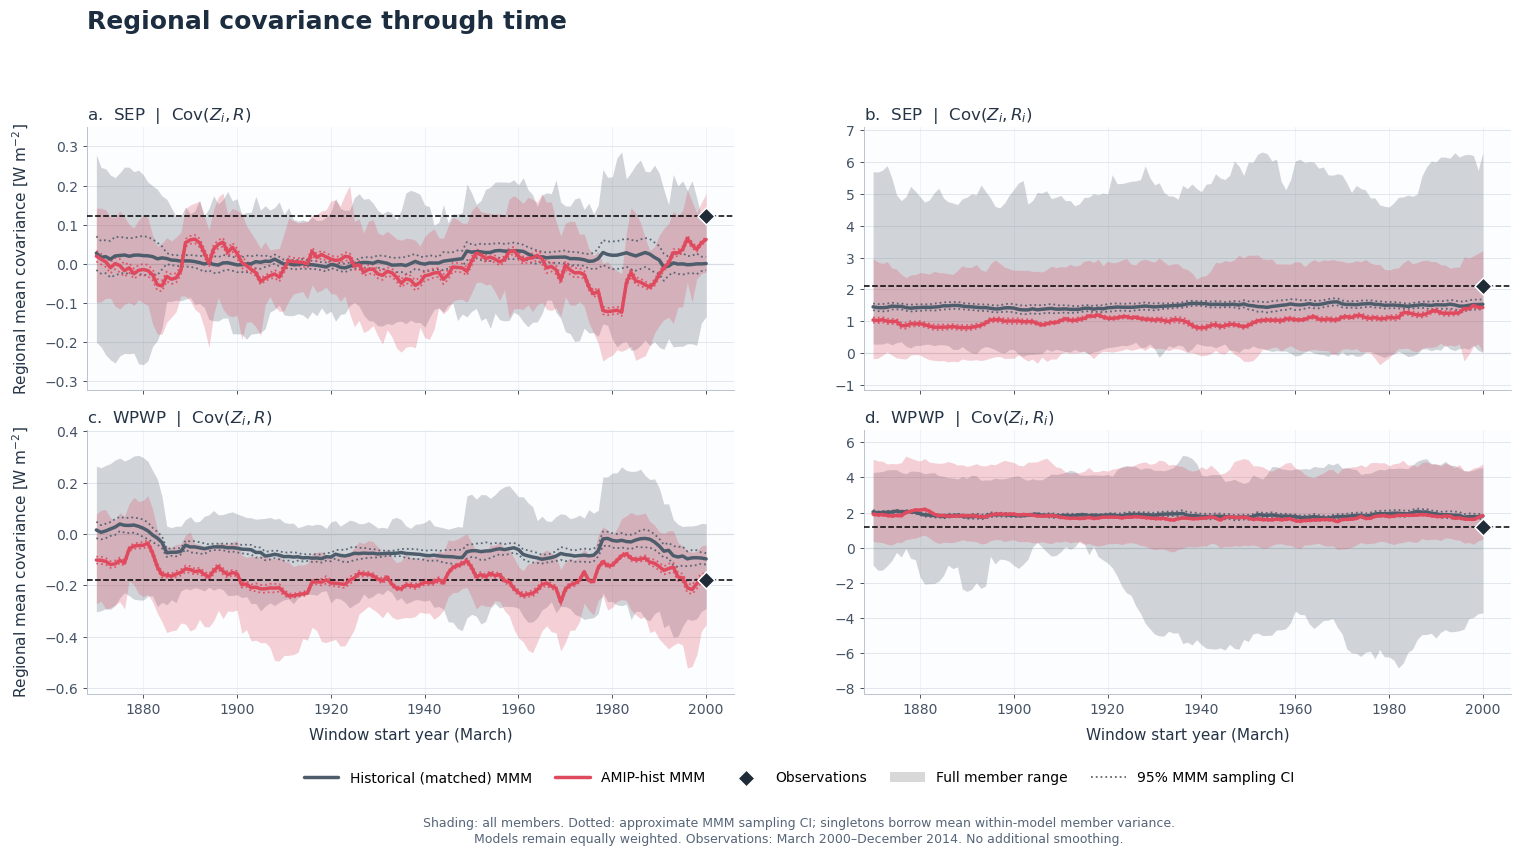

In [18]:
# %% Four panels: SEP/WPWP MMMs, all-member ranges, and finite-ensemble MMM CIs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats
from pathlib import Path

# Read only the small REGIONAL result bundle, not the original map files.
# Alternatively, replace this load with regional_plot_archive = loaded_regional
# or regional_plot_archive = stationarity_regional_archive for unsaved results.
regional_plot_path = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/regional/march_n178_regional.npy")
regional_plot_archive = np.load(regional_plot_path, allow_pickle=True).item()

# Matched historical is the default; choose historical for all coupled models.
# Members are pooled ONLY to find the descriptive min/max;
# the MMM and its confidence interval continue to give each model equal weight.
historical_group = "historical_matched"   # Or "historical" for all coupled models.
regional_plot_experiments = [historical_group, "amip_hist"]
regional_plot_regions = ["SEP", "WPWP"]
regional_plot_quantities = ["cov_Zi_R", "cov_Zi_Ri"]
regional_plot_colors = {historical_group: "#4E5D6C", "amip_hist": "#E04A5F"}
regional_plot_labels = {historical_group: "Historical" if historical_group == "historical" else "Historical (matched)",
                        "amip_hist": "AMIP-hist"}
regional_plot_titles = {"cov_Zi_R": r"$\mathrm{Cov}(Z_i,R)$", "cov_Zi_Ri": r"$\mathrm{Cov}(Z_i,R_i)$"}
regional_plot_alpha, regional_plot_lw = 0.25, 2.5
regional_plot_ci_lw, regional_plot_confidence = 1.3, 0.95  # Set confidence=0.80 for an 80% CI.
regional_plot_savepath = "/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/maps/MMM_historical.png"
# Set regional_plot_savepath = None to disable the figure save from your pasted cell.

# The x coordinate is WINDOW START YEAR, not the window midpoint/end year.
# The observation represents March 2000–December 2014 and therefore sits at 2000,
# exactly aligned with the final model window, not displaced to 2001 for display.
regional_plot_years = np.asarray(regional_plot_archive["metadata"]["start_years"])
regional_plot_obs_year = int(regional_plot_archive["metadata"]["observation_period"][:4])
if (regional_plot_years.ndim != 1 or not len(regional_plot_years)
        or not np.isfinite(regional_plot_years).all() or np.any(np.diff(regional_plot_years) <= 0)):
    raise ValueError("Expected finite, increasing window-start years.")


def regional_plot_mean(values):
    """Finite arithmetic mean over axis 0, with counts; empty years remain NaN."""
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan, dtype=float), where=count > 0), count


def regional_plot_mmm_ci(MMM, member_counts, member_variances, confidence=0.95):
    """Approximate pointwise CI for a fixed set of equally weighted model means.

    member_counts and member_variances have shape (model, start_year). Variances
    are WITHIN-model sample variances (ddof=1), not variance across model means.
    Assumes independent member sampling and independent sampling errors between
    models, with approximately normal mean errors. Singletons borrow the equal-
    model mean WITHIN-member variance from models with n>=2 in this same window.
    This assumes transferability of that variance, not equal precision of means.
    No donor model -> no CI. Imputed copies are not new variance information.
    """
    if not 0 < confidence < 1:
        raise ValueError("Confidence must be between 0 and 1.")
    n_years = len(MMM)
    if member_counts.shape != member_variances.shape or member_counts.shape[1:] != (n_years,):
        raise ValueError("Expected matching (model, start_year) counts and variances.")
    se, df, lower, upper = [np.full(n_years, np.nan) for _ in range(4)]
    singleton_count = (member_counts == 1).sum(axis=0)
    valid_donors = (member_counts >= 2) & np.isfinite(member_variances) & (member_variances >= 0)
    donor_count = valid_donors.sum(axis=0)
    borrowed_variance = np.full(n_years, np.nan)
    variance_used = np.where(valid_donors, member_variances, np.nan)
    borrowed_models = np.zeros(member_counts.shape, dtype=bool)

    # At each window, SE(MMM)^2 = sum(s_m^2/n_m)/M^2. Different ensemble sizes
    # change PRECISION, not the model weights in the MMM. No division by the
    # number of years: overlapping windows are not additional ensemble members.
    for year in range(n_years):
        contributes = member_counts[:, year] > 0
        n = member_counts[contributes, year]
        variances = member_variances[contributes, year]
        donors, singletons = n >= 2, n == 1
        donor_n, donor_variance = n[donors], variances[donors]
        if (not donors.any() or not np.isfinite(MMM[year])
                or not np.isfinite(donor_variance).all() or np.any(donor_variance < 0)):
            continue

        # Borrow VARIANCE, not the donors' already-reduced mean uncertainty s^2/n.
        # Each donor gets one vote in this estimate, regardless of ensemble size.
        # The raw variance array stays NaN for singletons; save imputation separately.
        n_singletons, n_donors = singletons.sum(), donors.sum()
        if n_singletons:
            borrowed_variance[year] = donor_variance.mean()
            singleton_rows = member_counts[:, year] == 1
            variance_used[singleton_rows, year] = borrowed_variance[year]
            borrowed_models[singleton_rows, year] = True

        # V(MMM) = [sum_d(s_d^2/n_d) + S*mean_d(s_d^2)]/M^2.
        # Regroup by each INDEPENDENT donor variance estimate for the t adjustment:
        # its coefficient is (1/n_d + S/D)/M^2. Borrowing the same estimates for
        # S singletons must not create S fictitious independent variance estimates.
        variance_terms = donor_variance * (1. / donor_n + n_singletons / n_donors) / len(n)**2
        variance_of_MMM = variance_terms.sum()
        se[year] = np.sqrt(variance_of_MMM)
        if variance_of_MMM == 0:
            # All estimated within-model variances are zero. This gives zero
            # estimated sampling error, not proof of zero population uncertainty.
            df[year], lower[year], upper[year] = np.inf, MMM[year], MMM[year]
            continue

        # Welch–Satterthwaite accounts approximately for uncertainty in each
        # estimated variance. Using variance shares avoids unnecessarily squaring
        # small physical-unit variances. Student-t is wider for low effective df.
        shares = variance_terms / variance_of_MMM
        df[year] = 1. / np.sum(shares**2 / (donor_n - 1))
        halfwidth = stats.t.ppf((1 + confidence) / 2, df[year]) * se[year]
        lower[year], upper[year] = MMM[year] - halfwidth, MMM[year] + halfwidth
    return {"MMM_se": se, "ci_df": df, "ci_lower": lower, "ci_upper": upper,
            "ci_available": np.isfinite(lower) & np.isfinite(upper), "ci_singleton_models": singleton_count,
            "ci_donor_models": donor_count, "ci_borrowed_member_variance": borrowed_variance,
            "model_member_variance_used": variance_used, "ci_borrowed_models": borrowed_models}


# Summarize each member series INTO ITS MODEL first, then give each model one
# vote in the MMM. Full-range shading now spans ALL individual member values.
# Models with more members have more opportunities to supply extreme values;
# that envelope is descriptive and is not an equal-model probability interval.
# Dotted lines now show an approximate CI for the fixed-model MMM, NOT the old
# 10th/90th model percentiles. Model choice, structural bias, observational error,
# and (for AMIP) uncertainty in the prescribed SST record are outside this CI.
regional_plot_summary = {e: {} for e in regional_plot_experiments}
for experiment in regional_plot_experiments:
    names = list(regional_plot_archive["metadata"]["model_names"][experiment])
    if not names or len(names) != len(set(names)):
        raise ValueError(f"{experiment}: expected a nonempty list of unique model names.")
    for quantity in regional_plot_quantities:
        regional_plot_summary[experiment][quantity] = {}
        for region in regional_plot_regions:
            model_means, member_counts, member_variances, all_members = [], [], [], []
            for model in names:
                members = np.ma.asarray(regional_plot_archive["member_values"][experiment][quantity][region][model],
                                        dtype=float).filled(np.nan)
                if members.ndim != 2 or members.shape[0] == 0 or members.shape[1] != len(regional_plot_years):
                    raise ValueError(f"{experiment}/{quantity}/{region}/{model}: expected (member, start_year).")
                mean, count = regional_plot_mean(members)
                # Estimate each model's member-to-member variance at this window.
                # Mask before subtraction so missing/inf inputs cannot contaminate
                # the sum. n=0 or 1 gives NaN variance, never a substituted zero.
                finite = np.isfinite(members)
                residual = np.where(finite, members, 0.) - np.where(np.isfinite(mean), mean, 0.)
                squared_deviations = np.sum(np.where(finite, residual, 0.)**2, axis=0)
                variance = np.divide(squared_deviations, count - 1, out=np.full_like(mean, np.nan), where=count >= 2)
                model_means.append(mean)
                member_counts.append(count)
                member_variances.append(variance)
                all_members.append(members)
            model_means = np.stack(model_means)
            member_counts, member_variances = np.stack(member_counts), np.stack(member_variances)
            MMM, n_models = regional_plot_mean(model_means)
            pooled_members = np.concatenate(all_members, axis=0)
            finite = np.isfinite(pooled_members)
            n_members = finite.sum(axis=0)
            lower = np.where(n_members > 0, np.min(np.where(finite, pooled_members, np.inf), axis=0), np.nan)
            upper = np.where(n_members > 0, np.max(np.where(finite, pooled_members, -np.inf), axis=0), np.nan)
            ci = regional_plot_mmm_ci(MMM, member_counts, member_variances, regional_plot_confidence)
            regional_plot_summary[experiment][quantity][region] = {
                "model_names": names.copy(), "model_means": model_means, "MMM": MMM,
                "member_minimum": lower, "member_maximum": upper, "n_models": n_models, "n_members": n_members,
                "model_n_members": member_counts, "model_member_variance": member_variances, **ci,
            }
            borrowed_names = [name for i, name in enumerate(names) if ci["ci_borrowed_models"][i].any()]
            print(f"{experiment}/{quantity}/{region}: CI defined for {ci['ci_available'].sum()}/{(n_models > 0).sum()} nonempty years."
                  + (f" Borrowed member variance for: {', '.join(borrowed_names)}." if borrowed_names else "")
                  + (f" No-donor windows: {np.sum((n_models > 0) & (ci['ci_donor_models'] == 0))}."))

# Keep interpretation beside the plotting results; the saved input is untouched.
regional_plot_ci_metadata = {
    "confidence": regional_plot_confidence, "target": "Expected equal-model MMM for this fixed model set",
    "method": "Independent mean-error propagation; Welch-Satterthwaite t interval grouping reused variance estimates by donor",
    "singleton_policy": "Borrow equal-model mean within-member variance from n>=2 models in the same experiment/quantity/region/window",
    "borrowing_assumption": "Singleton population member variance equals mean donor population member variance; no extra transfer-error allowance",
    "no_donor_policy": "CI undefined if no within-member variance can be estimated at that window",
    "coverage": "Approximate pointwise interval, not a simultaneous confidence band across overlapping years",
    "excluded": "Model selection, structural/shared bias, observation uncertainty, and prescribed-SST uncertainty",
    "sources": "Annotated bibliography entries 31–33; covariance/MMM implementation is a project adaptation",
}

# Preserve your revised presentation: independent y limits, matched historical,
# gray/red colors, 16x9 figure, tighter row spacing, and the original save location.
fig_regional_stationarity, axes_regional_stationarity = plt.subplots(2, 2, figsize=(16, 9), sharex=True,
                                                                  facecolor="white")
fig_regional_stationarity.subplots_adjust(left=.085, right=.975, bottom=.19, top=.82, wspace=.20, hspace=.150)
for row, region in enumerate(regional_plot_regions):
    for column, quantity in enumerate(regional_plot_quantities):
        ax = axes_regional_stationarity[row, column]
        for experiment in regional_plot_experiments:
            summary = regional_plot_summary[experiment][quantity][region]
            color = regional_plot_colors[experiment]
            ax.fill_between(regional_plot_years, summary["member_minimum"], summary["member_maximum"],
                            where=summary["n_members"] >= 2, color=color, alpha=regional_plot_alpha, linewidth=0, zorder=1)

            # Undefined intervals stay NaN, so lines have gaps (or are absent).
            # Singletons remain in the MMM; they borrow donor variance for the CI.
            for key in ["ci_lower", "ci_upper"]:
                ax.plot(regional_plot_years, summary[key], color=color, lw=regional_plot_ci_lw,
                        linestyle=":", alpha=.9, zorder=2)
            ax.plot(regional_plot_years, summary["MMM"], color=color, lw=regional_plot_lw,
                    label=f"{regional_plot_labels[experiment]} MMM", solid_capstyle="round", zorder=4)

        # The horizontal dashed line shows this panel's observed covariance VALUE.
        # It is a fixed reference, not observations measured in every model window.
        observation = float(regional_plot_archive["observations"][quantity][region])
        if np.isfinite(observation):
            ax.axhline(observation, color="black", lw=1.1, linestyle="--", zorder=3)
        ax.scatter([regional_plot_obs_year], [observation], marker="D", s=75, color="#202B38",
                   edgecolors="white", linewidths=1.1, label="Observations", zorder=6)
        ax.axhline(0, color="0.55", lw=.8, linestyle="-", alpha=.6, zorder=0)
        ax.set_title(f"{'abcd'[2*row+column]}.  {region}  |  {regional_plot_titles[quantity]}",
                     fontsize=12, fontweight="medium", color="#253446", loc="left", pad=5)
        undefined_groups = [regional_plot_labels[e] for e in regional_plot_experiments
                            if not regional_plot_summary[e][quantity][region]["ci_available"].any()]
        if undefined_groups:
            ax.text(.015, .975, "CI unavailable: " + ", ".join(undefined_groups), transform=ax.transAxes,
                    ha="left", va="top", fontsize=8.5, color="#566578",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=.8, pad=2))
        ax.set_xlim(min(regional_plot_years[0], regional_plot_obs_year) - 2,
                    max(regional_plot_years[-1], regional_plot_obs_year) + 6)
        ax.set_facecolor("#FCFDFE")
        ax.set_axisbelow(True)
        ax.grid(axis="y", color="#DDE3EA", linewidth=.6)
        ax.grid(axis="x", color="#E9EDF2", linewidth=.5)
        ax.spines[["top", "right"]].set_visible(False)
        for side in ["bottom", "left"]:
            ax.spines[side].set_color("#B9C3CF")
            ax.spines[side].set_linewidth(.7)
        ax.tick_params(axis="both", labelsize=10, colors="#445264", length=3, width=.7)
        ax.margins(y=.12)
        if row == 1:
            ax.set_xlabel("Window start year (March)", fontsize=11, labelpad=8, color="#253446")
        if column == 0:
            ax.set_ylabel(r"Regional mean covariance [W m$^{-2}$]", fontsize=11, labelpad=9, color="#253446")

handles, labels = axes_regional_stationarity[0, 0].get_legend_handles_labels()
handles += [Patch(facecolor="0.4", alpha=regional_plot_alpha, edgecolor="none"),
            Line2D([], [], color="0.4", lw=regional_plot_ci_lw, linestyle=":")]
labels += ["Full member range", f"{100 * regional_plot_confidence:g}% MMM sampling CI"]
fig_regional_stationarity.legend(handles, labels, loc="lower center", bbox_to_anchor=(.53, .075),
                                 ncol=5, frameon=False, fontsize=10, handlelength=2.5, columnspacing=1.7)
fig_regional_stationarity.suptitle("Regional covariance through time", fontsize=18, fontweight="bold",
                                   x=.085, y=.95, ha="left", color="#1D2D40")
window_months = regional_plot_archive["metadata"].get("window_months", 178)
# Optional subtitle, left disabled as in your revised presentation.
# fig_regional_stationarity.text(.085, .91, f"{window_months}-month windows · Equal model weighting · Black dashed: observed covariance",
#                                fontsize=10.5, color="#566578", ha="left")
fig_regional_stationarity.text(.53, .025,
                               "Shading: all members. Dotted: approximate MMM sampling CI; singletons borrow mean within-model member variance.\n"
                               "Models remain equally weighted. Observations: March 2000–December 2014. No additional smoothing.",
                               ha="center", fontsize=9, color="#566578")
if regional_plot_savepath is not None:
    regional_plot_savepath = Path(regional_plot_savepath)
    regional_plot_savepath.parent.mkdir(parents=True, exist_ok=True)
    fig_regional_stationarity.savefig(regional_plot_savepath, dpi=200, bbox_inches="tight")
plt.show()


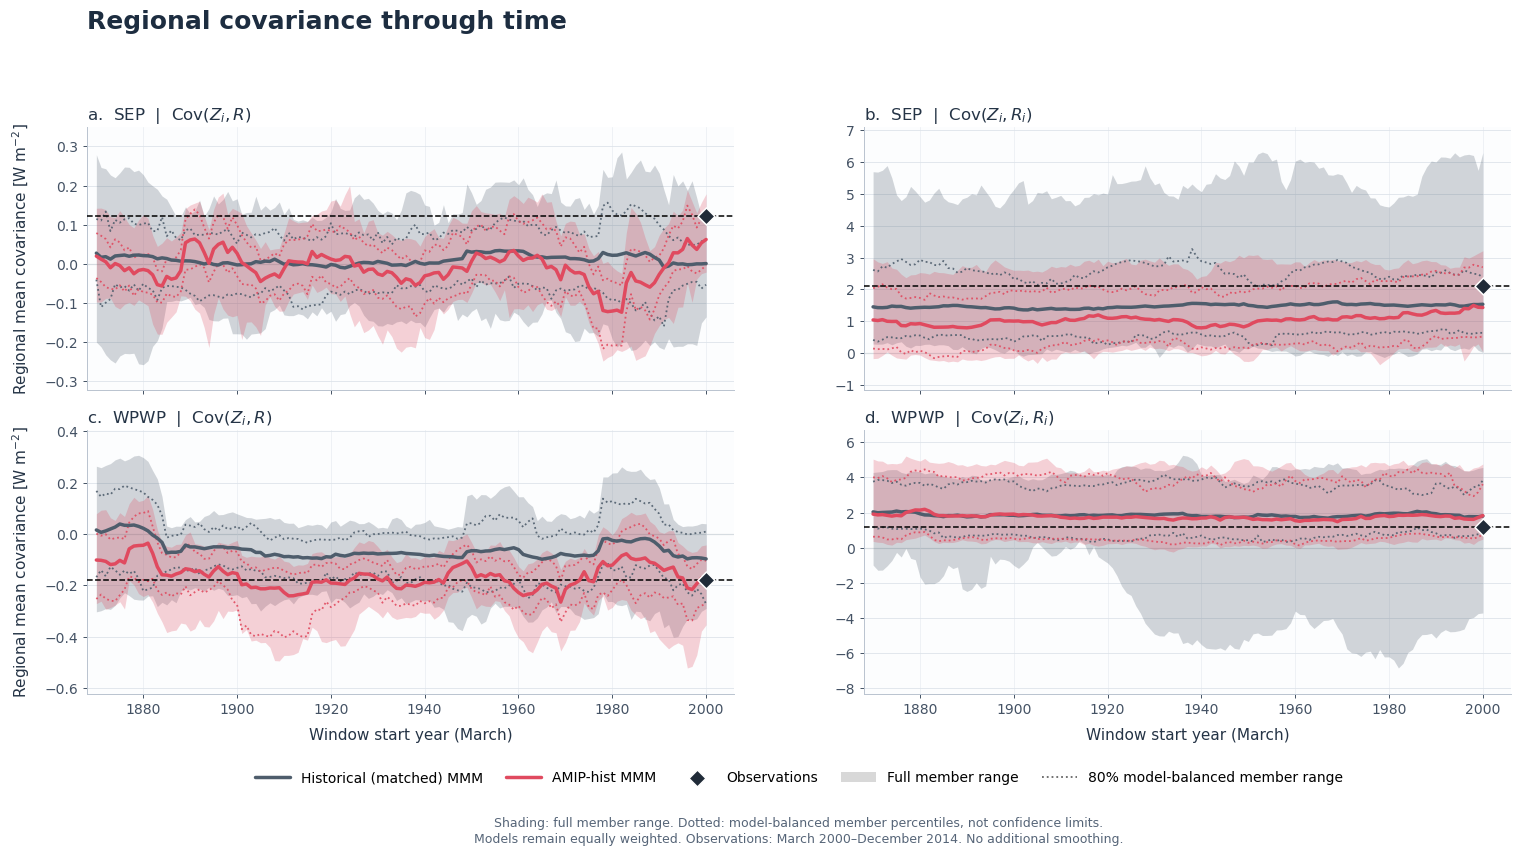

In [19]:
# %% Four panels: SEP/WPWP MMMs, all-member ranges, and model-balanced 80% member spread
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path

# Read only the small REGIONAL result bundle, not the original map files.
# Alternatively, replace this load with regional_plot_archive = loaded_regional
# or regional_plot_archive = stationarity_regional_archive for unsaved results.
regional_plot_path = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/regional/march_n178_regional.npy")
regional_plot_archive = np.load(regional_plot_path, allow_pickle=True).item()

# Matched historical is the default; choose historical for all coupled models.
# The MMM and member percentiles give each model equal total weight.
# The full min/max shading includes every finite member, regardless of weights.
historical_group = "historical_matched"   # Or "historical" for all coupled models.
regional_plot_experiments = [historical_group, "amip_hist"]
regional_plot_regions = ["SEP", "WPWP"]
regional_plot_quantities = ["cov_Zi_R", "cov_Zi_Ri"]
regional_plot_colors = {historical_group: "#4E5D6C", "amip_hist": "#E04A5F"}
regional_plot_labels = {historical_group: "Historical" if historical_group == "historical" else "Historical (matched)",
                        "amip_hist": "AMIP-hist"}
regional_plot_titles = {"cov_Zi_R": r"$\mathrm{Cov}(Z_i,R)$", "cov_Zi_Ri": r"$\mathrm{Cov}(Z_i,R_i)$"}
regional_plot_alpha, regional_plot_lw = 0.25, 2.5
regional_plot_percentile_lw, regional_plot_spread = 1.3, 0.80  # Central 80%: 10th/90th percentiles.
if not 0 < regional_plot_spread <= 1:
    raise ValueError("regional_plot_spread must be between 0 (exclusive) and 1.")
regional_plot_probabilities = np.array([(1 - regional_plot_spread)/2, (1 + regional_plot_spread)/2])
regional_plot_savepath = "/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/maps/MMM_historical.png"
# Set regional_plot_savepath = None to disable the figure save from your pasted cell.

# The x coordinate is WINDOW START YEAR, not the window midpoint/end year.
# The observation represents March 2000–December 2014 and therefore sits at 2000,
# exactly aligned with the final model window, not displaced to 2001 for display.
regional_plot_years = np.asarray(regional_plot_archive["metadata"]["start_years"])
regional_plot_obs_year = int(regional_plot_archive["metadata"]["observation_period"][:4])
if (regional_plot_years.ndim != 1 or not len(regional_plot_years)
        or not np.isfinite(regional_plot_years).all() or np.any(np.diff(regional_plot_years) <= 0)):
    raise ValueError("Expected finite, increasing window-start years.")


def regional_plot_mean(values):
    """Finite arithmetic mean over axis 0, with counts; empty years remain NaN."""
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan, dtype=float), where=count > 0), count


def regional_plot_weighted_quantile(values, weights, probabilities):
    """Inverse weighted empirical CDF: first observed value reaching each probability.

    No interpolation between members. Discrete jumps/ties mean the interval may
    contain more than the nominal 80% of weight, especially with few models.
    Finite values with positive finite weights contribute; empty support -> NaN.
    """
    values, weights = np.asarray(values, dtype=float), np.asarray(weights, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    if values.ndim != 1 or weights.shape != values.shape:
        raise ValueError("Expected matching one-dimensional values and weights.")
    if (probabilities.ndim != 1 or not np.isfinite(probabilities).all()
            or np.any((probabilities < 0) | (probabilities > 1))):
        raise ValueError("Probabilities must be a finite 1-D array between 0 and 1.")
    if np.any(weights < 0):
        raise ValueError("Weights cannot be negative.")
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not valid.any():
        return np.full(probabilities.shape, np.nan)

    # Sort member values and accumulate their probability weights. A quantile
    # is the first value whose cumulative weight reaches the requested fraction.
    values, weights = values[valid], weights[valid]
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cumulative = np.cumsum(weights / weights.max())
    cumulative /= cumulative[-1]
    # Allow only floating-point roundoff at an exact CDF boundary, so duplicating
    # a model's empirical member distribution does not move a boundary by one rank.
    indices = np.searchsorted(cumulative, np.maximum(0., probabilities - 8*np.finfo(float).eps), side="left")
    indices = np.where(probabilities == 1, len(values) - 1, indices)
    return values[np.minimum(indices, len(values) - 1)]


# Summarize each member series INTO ITS MODEL first, then give each model one
# vote in the MMM. Full-range shading now spans ALL individual member values.
# Models with more members have more opportunities to supply extreme values;
# that envelope is descriptive and is not an equal-model probability interval.
# Dotted lines are weighted percentiles of MEMBER VALUES, not percentiles of
# model means or a CI on the MMM. They include both within- and between-model
# spread. Each model gets total weight 1/M, divided among its valid members.
regional_plot_summary = {e: {} for e in regional_plot_experiments}
for experiment in regional_plot_experiments:
    names = list(regional_plot_archive["metadata"]["model_names"][experiment])
    if not names or len(names) != len(set(names)):
        raise ValueError(f"{experiment}: expected a nonempty list of unique model names.")
    for quantity in regional_plot_quantities:
        regional_plot_summary[experiment][quantity] = {}
        for region in regional_plot_regions:
            model_means, member_counts, all_members = [], [], []
            for model in names:
                members = np.ma.asarray(regional_plot_archive["member_values"][experiment][quantity][region][model],
                                        dtype=float).filled(np.nan)
                if members.ndim != 2 or members.shape[0] == 0 or members.shape[1] != len(regional_plot_years):
                    raise ValueError(f"{experiment}/{quantity}/{region}/{model}: expected (member, start_year).")
                mean, count = regional_plot_mean(members)
                model_means.append(mean)
                member_counts.append(count)
                all_members.append(members)
            model_means = np.stack(model_means)
            member_counts = np.stack(member_counts)
            MMM, n_models = regional_plot_mean(model_means)
            pooled_members = np.concatenate(all_members, axis=0)
            finite = np.isfinite(pooled_members)
            n_members = finite.sum(axis=0)
            lower = np.where(n_members > 0, np.min(np.where(finite, pooled_members, np.inf), axis=0), np.nan)
            upper = np.where(n_members > 0, np.max(np.where(finite, pooled_members, -np.inf), axis=0), np.nan)
            # At this window each valid member in model m gets 1/(M*n_m).
            # Models with no valid members get zero weight; the remaining models
            # each retain one vote. A singleton receives its model's full weight.
            model_member_weight = np.divide(1., member_counts * n_models[None, :],
                                            out=np.zeros_like(model_means), where=member_counts > 0)
            pooled_weights = np.concatenate([np.where(np.isfinite(members), model_member_weight[i], 0.)
                                             for i, members in enumerate(all_members)], axis=0)

            # Summarize the weighted empirical member distribution independently
            # at each window. No variance estimates, borrowing, or time smoothing.
            bounds = np.full((2, len(regional_plot_years)), np.nan)
            for year in range(len(regional_plot_years)):
                bounds[:, year] = regional_plot_weighted_quantile(pooled_members[:, year], pooled_weights[:, year],
                                                                 regional_plot_probabilities)
            regional_plot_summary[experiment][quantity][region] = {
                "model_names": names.copy(), "model_means": model_means, "MMM": MMM,
                "member_minimum": lower, "member_maximum": upper, "n_models": n_models, "n_members": n_members,
                "model_n_members": member_counts, "model_member_weight": model_member_weight,
                "spread_lower": bounds[0], "spread_upper": bounds[1],
                "spread_available": np.isfinite(bounds).all(axis=0),
            }

# Keep the definition beside the plotting results; the saved input is untouched.
regional_plot_spread_metadata = {
    "central_fraction": regional_plot_spread, "quantile_probabilities": regional_plot_probabilities.copy(),
    "target": "Descriptive member-value distribution with equal model representation, independently at each window",
    "member_weight": "1/(M*n_m), using finite member and contributing model counts at that window",
    "quantile_method": "Inverse weighted empirical CDF; observed-value endpoints, no interpolation; roundoff tolerance 8*float eps",
    "singleton_policy": "One observed value with full model weight; no variance borrowing or estimate of unseen spread",
    "interpretation": "Within-model plus between-model spread; not a confidence interval or a probability statement about reality",
    "missingness": "Omit nonfinite members; renormalize available models equally; no data -> NaN",
}

# Preserve your revised presentation: independent y limits, matched historical,
# gray/red colors, 16x9 figure, tighter row spacing, and the original save location.
fig_regional_stationarity, axes_regional_stationarity = plt.subplots(2, 2, figsize=(16, 9), sharex=True,
                                                                  facecolor="white")
fig_regional_stationarity.subplots_adjust(left=.085, right=.975, bottom=.19, top=.82, wspace=.20, hspace=.150)
for row, region in enumerate(regional_plot_regions):
    for column, quantity in enumerate(regional_plot_quantities):
        ax = axes_regional_stationarity[row, column]
        for experiment in regional_plot_experiments:
            summary = regional_plot_summary[experiment][quantity][region]
            color = regional_plot_colors[experiment]
            ax.fill_between(regional_plot_years, summary["member_minimum"], summary["member_maximum"],
                            where=summary["n_members"] >= 2, color=color, alpha=regional_plot_alpha, linewidth=0, zorder=1)

            # Empty windows stay NaN. One observed value gives coincident bounds;
            # singletons are included directly, without estimating extra spread.
            for key in ["spread_lower", "spread_upper"]:
                ax.plot(regional_plot_years, summary[key], color=color, lw=regional_plot_percentile_lw,
                        linestyle=":", alpha=.9, zorder=2)
            ax.plot(regional_plot_years, summary["MMM"], color=color, lw=regional_plot_lw,
                    label=f"{regional_plot_labels[experiment]} MMM", solid_capstyle="round", zorder=4)

        # The horizontal dashed line shows this panel's observed covariance VALUE.
        # It is a fixed reference, not observations measured in every model window.
        observation = float(regional_plot_archive["observations"][quantity][region])
        if np.isfinite(observation):
            ax.axhline(observation, color="black", lw=1.1, linestyle="--", zorder=3)
        ax.scatter([regional_plot_obs_year], [observation], marker="D", s=75, color="#202B38",
                   edgecolors="white", linewidths=1.1, label="Observations", zorder=6)
        ax.axhline(0, color="0.55", lw=.8, linestyle="-", alpha=.6, zorder=0)
        ax.set_title(f"{'abcd'[2*row+column]}.  {region}  |  {regional_plot_titles[quantity]}",
                     fontsize=12, fontweight="medium", color="#253446", loc="left", pad=5)
        undefined_groups = [regional_plot_labels[e] for e in regional_plot_experiments
                            if not regional_plot_summary[e][quantity][region]["spread_available"].any()]
        if undefined_groups:
            ax.text(.015, .975, "No member data: " + ", ".join(undefined_groups), transform=ax.transAxes,
                    ha="left", va="top", fontsize=8.5, color="#566578",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=.8, pad=2))
        ax.set_xlim(min(regional_plot_years[0], regional_plot_obs_year) - 2,
                    max(regional_plot_years[-1], regional_plot_obs_year) + 6)
        ax.set_facecolor("#FCFDFE")
        ax.set_axisbelow(True)
        ax.grid(axis="y", color="#DDE3EA", linewidth=.6)
        ax.grid(axis="x", color="#E9EDF2", linewidth=.5)
        ax.spines[["top", "right"]].set_visible(False)
        for side in ["bottom", "left"]:
            ax.spines[side].set_color("#B9C3CF")
            ax.spines[side].set_linewidth(.7)
        ax.tick_params(axis="both", labelsize=10, colors="#445264", length=3, width=.7)
        ax.margins(y=.12)
        if row == 1:
            ax.set_xlabel("Window start year (March)", fontsize=11, labelpad=8, color="#253446")
        if column == 0:
            ax.set_ylabel(r"Regional mean covariance [W m$^{-2}$]", fontsize=11, labelpad=9, color="#253446")

handles, labels = axes_regional_stationarity[0, 0].get_legend_handles_labels()
handles += [Patch(facecolor="0.4", alpha=regional_plot_alpha, edgecolor="none"),
            Line2D([], [], color="0.4", lw=regional_plot_percentile_lw, linestyle=":")]
labels += ["Full member range", f"{100 * regional_plot_spread:g}% model-balanced member range"]
fig_regional_stationarity.legend(handles, labels, loc="lower center", bbox_to_anchor=(.53, .075),
                                 ncol=5, frameon=False, fontsize=10, handlelength=2.5, columnspacing=1.7)
fig_regional_stationarity.suptitle("Regional covariance through time", fontsize=18, fontweight="bold",
                                   x=.085, y=.95, ha="left", color="#1D2D40")
window_months = regional_plot_archive["metadata"].get("window_months", 178)
# Optional subtitle, left disabled as in your revised presentation.
# fig_regional_stationarity.text(.085, .91, f"{window_months}-month windows · Equal model weighting · Black dashed: observed covariance",
#                                fontsize=10.5, color="#566578", ha="left")
fig_regional_stationarity.text(.53, .025,
                               "Shading: full member range. Dotted: model-balanced member percentiles, not confidence limits.\n"
                               "Models remain equally weighted. Observations: March 2000–December 2014. No additional smoothing.",
                               ha="center", fontsize=9, color="#566578")
if regional_plot_savepath is not None:
    regional_plot_savepath = Path(regional_plot_savepath)
    regional_plot_savepath.parent.mkdir(parents=True, exist_ok=True)
    fig_regional_stationarity.savefig(regional_plot_savepath, dpi=200, bbox_inches="tight")
plt.show()


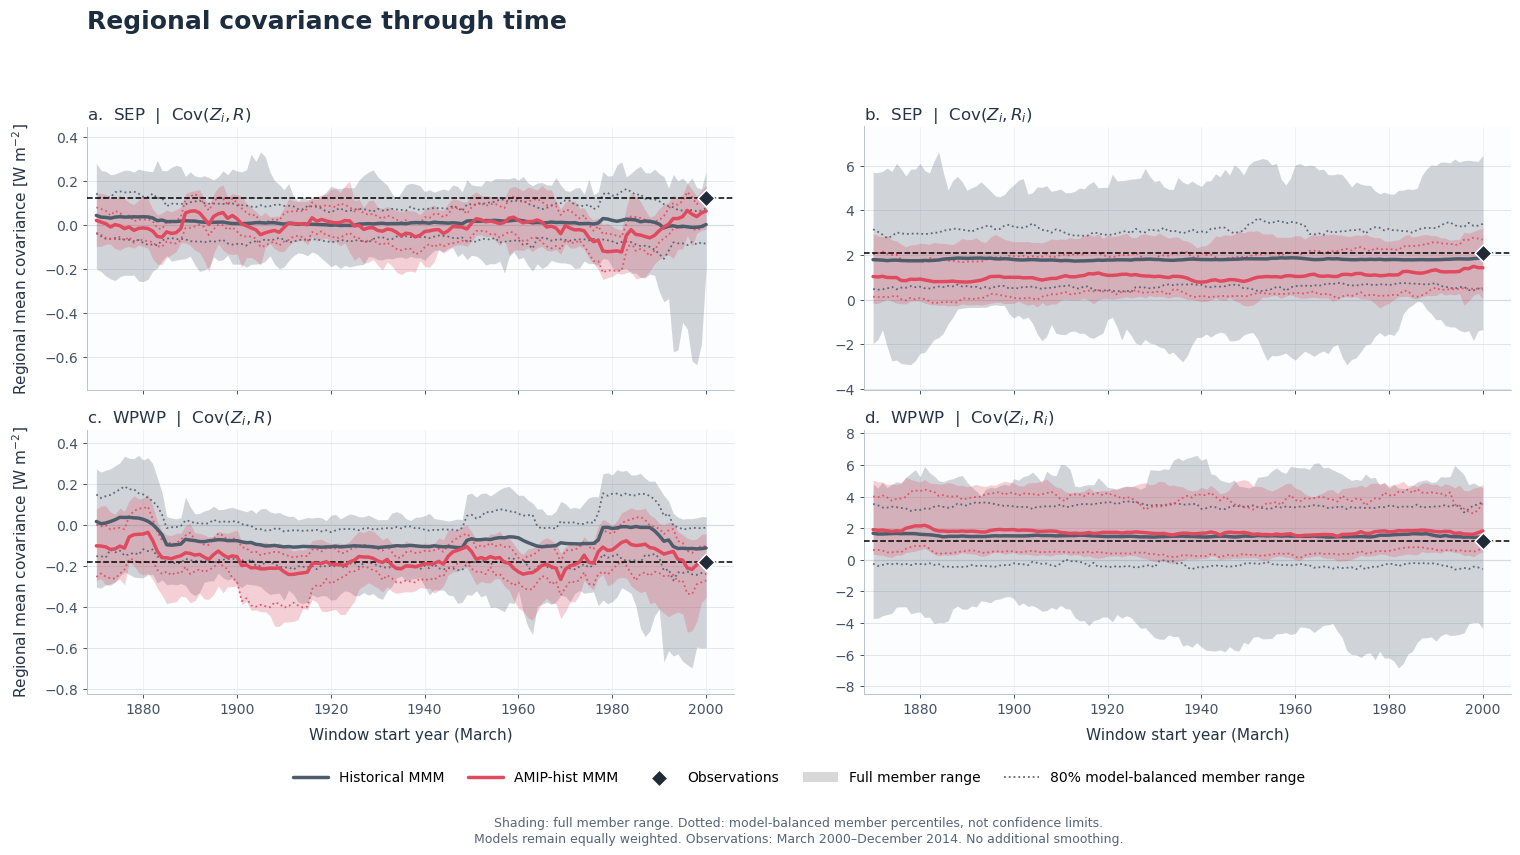

In [20]:
# %% Four panels: SEP/WPWP MMMs, all-member ranges, and model-balanced 80% member spread
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path

# Read only the small REGIONAL result bundle, not the original map files.
# Alternatively, replace this load with regional_plot_archive = loaded_regional
# or regional_plot_archive = stationarity_regional_archive for unsaved results.
regional_plot_path = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/regional/march_n178_regional.npy")
regional_plot_archive = np.load(regional_plot_path, allow_pickle=True).item()

# Matched historical is the default; choose historical for all coupled models.
# The MMM and member percentiles give each model equal total weight.
# The full min/max shading includes every finite member, regardless of weights.
historical_group = "historical"   # Or "historical" for all coupled models.
regional_plot_experiments = [historical_group, "amip_hist"]
regional_plot_regions = ["SEP", "WPWP"]
regional_plot_quantities = ["cov_Zi_R", "cov_Zi_Ri"]
regional_plot_colors = {historical_group: "#4E5D6C", "amip_hist": "#E04A5F"}
regional_plot_labels = {historical_group: "Historical" if historical_group == "historical" else "Historical (matched)",
                        "amip_hist": "AMIP-hist"}
regional_plot_titles = {"cov_Zi_R": r"$\mathrm{Cov}(Z_i,R)$", "cov_Zi_Ri": r"$\mathrm{Cov}(Z_i,R_i)$"}
regional_plot_alpha, regional_plot_lw = 0.25, 2.5
regional_plot_percentile_lw, regional_plot_spread = 1.3, 0.80  # Central 80%: 10th/90th percentiles.
if not 0 < regional_plot_spread <= 1:
    raise ValueError("regional_plot_spread must be between 0 (exclusive) and 1.")
regional_plot_probabilities = np.array([(1 - regional_plot_spread)/2, (1 + regional_plot_spread)/2])
regional_plot_savepath = "/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/maps/MMM_historical.png"
# Set regional_plot_savepath = None to disable the figure save from your pasted cell.

# The x coordinate is WINDOW START YEAR, not the window midpoint/end year.
# The observation represents March 2000–December 2014 and therefore sits at 2000,
# exactly aligned with the final model window, not displaced to 2001 for display.
regional_plot_years = np.asarray(regional_plot_archive["metadata"]["start_years"])
regional_plot_obs_year = int(regional_plot_archive["metadata"]["observation_period"][:4])
if (regional_plot_years.ndim != 1 or not len(regional_plot_years)
        or not np.isfinite(regional_plot_years).all() or np.any(np.diff(regional_plot_years) <= 0)):
    raise ValueError("Expected finite, increasing window-start years.")


def regional_plot_mean(values):
    """Finite arithmetic mean over axis 0, with counts; empty years remain NaN."""
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan, dtype=float), where=count > 0), count


def regional_plot_weighted_quantile(values, weights, probabilities):
    """Inverse weighted empirical CDF: first observed value reaching each probability.

    No interpolation between members. Discrete jumps/ties mean the interval may
    contain more than the nominal 80% of weight, especially with few models.
    Finite values with positive finite weights contribute; empty support -> NaN.
    """
    values, weights = np.asarray(values, dtype=float), np.asarray(weights, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    if values.ndim != 1 or weights.shape != values.shape:
        raise ValueError("Expected matching one-dimensional values and weights.")
    if (probabilities.ndim != 1 or not np.isfinite(probabilities).all()
            or np.any((probabilities < 0) | (probabilities > 1))):
        raise ValueError("Probabilities must be a finite 1-D array between 0 and 1.")
    if np.any(weights < 0):
        raise ValueError("Weights cannot be negative.")
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not valid.any():
        return np.full(probabilities.shape, np.nan)

    # Sort member values and accumulate their probability weights. A quantile
    # is the first value whose cumulative weight reaches the requested fraction.
    values, weights = values[valid], weights[valid]
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cumulative = np.cumsum(weights / weights.max())
    cumulative /= cumulative[-1]
    # Allow only floating-point roundoff at an exact CDF boundary, so duplicating
    # a model's empirical member distribution does not move a boundary by one rank.
    indices = np.searchsorted(cumulative, np.maximum(0., probabilities - 8*np.finfo(float).eps), side="left")
    indices = np.where(probabilities == 1, len(values) - 1, indices)
    return values[np.minimum(indices, len(values) - 1)]


# Summarize each member series INTO ITS MODEL first, then give each model one
# vote in the MMM. Full-range shading now spans ALL individual member values.
# Models with more members have more opportunities to supply extreme values;
# that envelope is descriptive and is not an equal-model probability interval.
# Dotted lines are weighted percentiles of MEMBER VALUES, not percentiles of
# model means or a CI on the MMM. They include both within- and between-model
# spread. Each model gets total weight 1/M, divided among its valid members.
regional_plot_summary = {e: {} for e in regional_plot_experiments}
for experiment in regional_plot_experiments:
    names = list(regional_plot_archive["metadata"]["model_names"][experiment])
    if not names or len(names) != len(set(names)):
        raise ValueError(f"{experiment}: expected a nonempty list of unique model names.")
    for quantity in regional_plot_quantities:
        regional_plot_summary[experiment][quantity] = {}
        for region in regional_plot_regions:
            model_means, member_counts, all_members = [], [], []
            for model in names:
                members = np.ma.asarray(regional_plot_archive["member_values"][experiment][quantity][region][model],
                                        dtype=float).filled(np.nan)
                if members.ndim != 2 or members.shape[0] == 0 or members.shape[1] != len(regional_plot_years):
                    raise ValueError(f"{experiment}/{quantity}/{region}/{model}: expected (member, start_year).")
                mean, count = regional_plot_mean(members)
                model_means.append(mean)
                member_counts.append(count)
                all_members.append(members)
            model_means = np.stack(model_means)
            member_counts = np.stack(member_counts)
            MMM, n_models = regional_plot_mean(model_means)
            pooled_members = np.concatenate(all_members, axis=0)
            finite = np.isfinite(pooled_members)
            n_members = finite.sum(axis=0)
            lower = np.where(n_members > 0, np.min(np.where(finite, pooled_members, np.inf), axis=0), np.nan)
            upper = np.where(n_members > 0, np.max(np.where(finite, pooled_members, -np.inf), axis=0), np.nan)
            # At this window each valid member in model m gets 1/(M*n_m).
            # Models with no valid members get zero weight; the remaining models
            # each retain one vote. A singleton receives its model's full weight.
            model_member_weight = np.divide(1., member_counts * n_models[None, :],
                                            out=np.zeros_like(model_means), where=member_counts > 0)
            pooled_weights = np.concatenate([np.where(np.isfinite(members), model_member_weight[i], 0.)
                                             for i, members in enumerate(all_members)], axis=0)

            # Summarize the weighted empirical member distribution independently
            # at each window. No variance estimates, borrowing, or time smoothing.
            bounds = np.full((2, len(regional_plot_years)), np.nan)
            for year in range(len(regional_plot_years)):
                bounds[:, year] = regional_plot_weighted_quantile(pooled_members[:, year], pooled_weights[:, year],
                                                                 regional_plot_probabilities)
            regional_plot_summary[experiment][quantity][region] = {
                "model_names": names.copy(), "model_means": model_means, "MMM": MMM,
                "member_minimum": lower, "member_maximum": upper, "n_models": n_models, "n_members": n_members,
                "model_n_members": member_counts, "model_member_weight": model_member_weight,
                "spread_lower": bounds[0], "spread_upper": bounds[1],
                "spread_available": np.isfinite(bounds).all(axis=0),
            }

# Keep the definition beside the plotting results; the saved input is untouched.
regional_plot_spread_metadata = {
    "central_fraction": regional_plot_spread, "quantile_probabilities": regional_plot_probabilities.copy(),
    "target": "Descriptive member-value distribution with equal model representation, independently at each window",
    "member_weight": "1/(M*n_m), using finite member and contributing model counts at that window",
    "quantile_method": "Inverse weighted empirical CDF; observed-value endpoints, no interpolation; roundoff tolerance 8*float eps",
    "singleton_policy": "One observed value with full model weight; no variance borrowing or estimate of unseen spread",
    "interpretation": "Within-model plus between-model spread; not a confidence interval or a probability statement about reality",
    "missingness": "Omit nonfinite members; renormalize available models equally; no data -> NaN",
}

# Preserve your revised presentation: independent y limits, matched historical,
# gray/red colors, 16x9 figure, tighter row spacing, and the original save location.
fig_regional_stationarity, axes_regional_stationarity = plt.subplots(2, 2, figsize=(16, 9), sharex=True,
                                                                  facecolor="white")
fig_regional_stationarity.subplots_adjust(left=.085, right=.975, bottom=.19, top=.82, wspace=.20, hspace=.150)
for row, region in enumerate(regional_plot_regions):
    for column, quantity in enumerate(regional_plot_quantities):
        ax = axes_regional_stationarity[row, column]
        for experiment in regional_plot_experiments:
            summary = regional_plot_summary[experiment][quantity][region]
            color = regional_plot_colors[experiment]
            ax.fill_between(regional_plot_years, summary["member_minimum"], summary["member_maximum"],
                            where=summary["n_members"] >= 2, color=color, alpha=regional_plot_alpha, linewidth=0, zorder=1)

            # Empty windows stay NaN. One observed value gives coincident bounds;
            # singletons are included directly, without estimating extra spread.
            for key in ["spread_lower", "spread_upper"]:
                ax.plot(regional_plot_years, summary[key], color=color, lw=regional_plot_percentile_lw,
                        linestyle=":", alpha=.9, zorder=2)
            ax.plot(regional_plot_years, summary["MMM"], color=color, lw=regional_plot_lw,
                    label=f"{regional_plot_labels[experiment]} MMM", solid_capstyle="round", zorder=4)

        # The horizontal dashed line shows this panel's observed covariance VALUE.
        # It is a fixed reference, not observations measured in every model window.
        observation = float(regional_plot_archive["observations"][quantity][region])
        if np.isfinite(observation):
            ax.axhline(observation, color="black", lw=1.1, linestyle="--", zorder=3)
        ax.scatter([regional_plot_obs_year], [observation], marker="D", s=75, color="#202B38",
                   edgecolors="white", linewidths=1.1, label="Observations", zorder=6)
        ax.axhline(0, color="0.55", lw=.8, linestyle="-", alpha=.6, zorder=0)
        ax.set_title(f"{'abcd'[2*row+column]}.  {region}  |  {regional_plot_titles[quantity]}",
                     fontsize=12, fontweight="medium", color="#253446", loc="left", pad=5)
        undefined_groups = [regional_plot_labels[e] for e in regional_plot_experiments
                            if not regional_plot_summary[e][quantity][region]["spread_available"].any()]
        if undefined_groups:
            ax.text(.015, .975, "No member data: " + ", ".join(undefined_groups), transform=ax.transAxes,
                    ha="left", va="top", fontsize=8.5, color="#566578",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=.8, pad=2))
        ax.set_xlim(min(regional_plot_years[0], regional_plot_obs_year) - 2,
                    max(regional_plot_years[-1], regional_plot_obs_year) + 6)
        ax.set_facecolor("#FCFDFE")
        ax.set_axisbelow(True)
        ax.grid(axis="y", color="#DDE3EA", linewidth=.6)
        ax.grid(axis="x", color="#E9EDF2", linewidth=.5)
        ax.spines[["top", "right"]].set_visible(False)
        for side in ["bottom", "left"]:
            ax.spines[side].set_color("#B9C3CF")
            ax.spines[side].set_linewidth(.7)
        ax.tick_params(axis="both", labelsize=10, colors="#445264", length=3, width=.7)
        ax.margins(y=.12)
        if row == 1:
            ax.set_xlabel("Window start year (March)", fontsize=11, labelpad=8, color="#253446")
        if column == 0:
            ax.set_ylabel(r"Regional mean covariance [W m$^{-2}$]", fontsize=11, labelpad=9, color="#253446")

handles, labels = axes_regional_stationarity[0, 0].get_legend_handles_labels()
handles += [Patch(facecolor="0.4", alpha=regional_plot_alpha, edgecolor="none"),
            Line2D([], [], color="0.4", lw=regional_plot_percentile_lw, linestyle=":")]
labels += ["Full member range", f"{100 * regional_plot_spread:g}% model-balanced member range"]
fig_regional_stationarity.legend(handles, labels, loc="lower center", bbox_to_anchor=(.53, .075),
                                 ncol=5, frameon=False, fontsize=10, handlelength=2.5, columnspacing=1.7)
fig_regional_stationarity.suptitle("Regional covariance through time", fontsize=18, fontweight="bold",
                                   x=.085, y=.95, ha="left", color="#1D2D40")
window_months = regional_plot_archive["metadata"].get("window_months", 178)
# Optional subtitle, left disabled as in your revised presentation.
# fig_regional_stationarity.text(.085, .91, f"{window_months}-month windows · Equal model weighting · Black dashed: observed covariance",
#                                fontsize=10.5, color="#566578", ha="left")
fig_regional_stationarity.text(.53, .025,
                               "Shading: full member range. Dotted: model-balanced member percentiles, not confidence limits.\n"
                               "Models remain equally weighted. Observations: March 2000–December 2014. No additional smoothing.",
                               ha="center", fontsize=9, color="#566578")
if regional_plot_savepath is not None:
    regional_plot_savepath = Path(regional_plot_savepath)
    regional_plot_savepath.parent.mkdir(parents=True, exist_ok=True)
    fig_regional_stationarity.savefig(regional_plot_savepath, dpi=200, bbox_inches="tight")
plt.show()
